## Fase 1. Inventario de fuentes disponibles

### Objetivo de la fase

En esta fase se realiza un inventario técnico de las fuentes de datos utilizadas en el proyecto WiFi CSI. El propósito es identificar la ubicación real de los archivos, su estructura, número de registros, columnas disponibles y utilidad para el análisis de detección de movimiento.

A diferencia de una lectura directa desde la raíz del proyecto, este notebook trabaja con una estructura organizada de carpetas. Por ello, las fuentes se buscan dentro de los directorios definidos previamente: `data/postgres`, `data/json` y `data/har_ort`.

### Relación con el entregable de Semana 3

Esta fase permite preparar correctamente la base de datos antes de construir las dimensiones y la tabla de hechos. Además, responde a la necesidad de fortalecer la relación entre las fuentes originales y el modelo analítico final.

### Relación con el paper

Para una futura investigación sobre detección de movimiento usando señales WiFi CSI, esta fase permite documentar qué datasets se tienen, qué tipo de registros contienen, qué etiquetas de actividad están disponibles y qué limitaciones iniciales presentan.

In [4]:
from pathlib import Path
import os
import json
import zipfile

import pandas as pd
import numpy as np
from dotenv import load_dotenv

In [5]:
load_dotenv()

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
POSTGRES_DATA_DIR = DATA_DIR / "postgres"
JSON_DIR = DATA_DIR / "json"
HAR_ORT_DIR = DATA_DIR / "har_ort"
PROCESSED_DIR = DATA_DIR / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("POSTGRES_DATA_DIR:", POSTGRES_DATA_DIR)
print("JSON_DIR:", JSON_DIR)
print("HAR_ORT_DIR:", HAR_ORT_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)

PROJECT_ROOT: c:\Users\Manuel\Desktop\proyectoWifi
DATA_DIR: c:\Users\Manuel\Desktop\proyectoWifi\data
POSTGRES_DATA_DIR: c:\Users\Manuel\Desktop\proyectoWifi\data\postgres
JSON_DIR: c:\Users\Manuel\Desktop\proyectoWifi\data\json
HAR_ORT_DIR: c:\Users\Manuel\Desktop\proyectoWifi\data\har_ort
PROCESSED_DIR: c:\Users\Manuel\Desktop\proyectoWifi\data\processed


In [6]:
print("Archivos encontrados en data:")

for path in DATA_DIR.rglob("*"):
    if path.is_file():
        print(path)

Archivos encontrados en data:
c:\Users\Manuel\Desktop\proyectoWifi\data\README.md
c:\Users\Manuel\Desktop\proyectoWifi\data\har_ort\annotations.csv
c:\Users\Manuel\Desktop\proyectoWifi\data\har_ort\fall_benja_2025-07-12_00-23-38.pcap
c:\Users\Manuel\Desktop\proyectoWifi\data\har_ort\fall_benja_2025-07-12_00-23-47.pcap
c:\Users\Manuel\Desktop\proyectoWifi\data\har_ort\fall_benja_2025-07-12_00-23-56.pcap
c:\Users\Manuel\Desktop\proyectoWifi\data\har_ort\fall_benja_2025-07-12_00-24-05.pcap
c:\Users\Manuel\Desktop\proyectoWifi\data\har_ort\fall_benja_2025-07-12_00-24-14.pcap
c:\Users\Manuel\Desktop\proyectoWifi\data\har_ort\fall_benja_2025-07-12_00-25-15.pcap
c:\Users\Manuel\Desktop\proyectoWifi\data\har_ort\fall_benja_2025-07-12_00-25-24.pcap
c:\Users\Manuel\Desktop\proyectoWifi\data\har_ort\fall_benja_2025-07-12_00-25-33.pcap
c:\Users\Manuel\Desktop\proyectoWifi\data\har_ort\fall_benja_2025-07-12_00-25-42.pcap
c:\Users\Manuel\Desktop\proyectoWifi\data\har_ort\fall_benja_2025-07-12_00-25-

In [7]:
ruta_object_csv = POSTGRES_DATA_DIR / "raw_data.csv"

if not ruta_object_csv.exists():
    raise FileNotFoundError(f"No se encontró el archivo: {ruta_object_csv}")

df_object = pd.read_csv(ruta_object_csv)

print("Object Detection:", df_object.shape)
df_object.head()

Object Detection: (56939, 109)


,amp_0,amp_1,amp_2,amp_3,amp_4,amp_5,amp_6,amp_7,amp_8,amp_9,...,phase_47,phase_48,phase_49,phase_50,phase_51,type,day,object_id,position,configuration
0,14.317821,15.524175,14.317821,15.524175,15.524175,14.866069,16.155494,14.866069,16.552945,15.652476,...,1.712693,1.723446,1.781890,1.781890,1.735945,organic,1,0,A10,COMPRIDO
1,19.209373,19.798990,18.439089,21.931712,20.518285,19.798990,20.518285,21.400935,22.203603,22.203603,...,2.010639,1.951303,1.951303,2.007423,2.034444,organic,1,0,A10,COMPRIDO
2,15.132746,15.132746,14.142136,15.132746,16.124515,15.033296,16.000000,16.031220,16.000000,16.031220,...,1.107149,1.176005,1.107149,1.071450,1.144169,organic,1,0,A10,COMPRIDO
3,12.649111,13.928388,13.000000,13.928388,14.317821,14.317821,15.652476,15.264338,15.264338,14.764823,...,0.083141,0.165149,0.076772,0.165149,0.165149,organic,1,0,A10,COMPRIDO
4,18.439089,19.416488,19.416488,21.587033,20.024984,21.213203,21.095023,22.022716,22.022716,22.022716,...,2.601173,2.651635,2.570255,2.601173,2.622447,organic,1,0,A10,COMPRIDO


In [8]:
json_files = list(JSON_DIR.rglob("*.json"))

print("Archivos JSON encontrados:")
for file in json_files:
    print(file)

if len(json_files) == 0:
    raise FileNotFoundError("No se encontraron archivos JSON dentro de data/json")

ruta_har_json = json_files[0]

with open(ruta_har_json, "r") as file:
    data_har = json.load(file)

print("Ruta usada:", ruta_har_json)
print("Cantidad de muestras:", len(data_har))
print("Dimensión primera muestra:", np.array(data_har[0]).shape)

Archivos JSON encontrados:
c:\Users\Manuel\Desktop\proyectoWifi\data\json\data_apml_min.json
Ruta usada: c:\Users\Manuel\Desktop\proyectoWifi\data\json\data_apml_min.json
Cantidad de muestras: 21298
Dimensión primera muestra: (9, 56)


In [9]:
registros_har = []

for i, muestra in enumerate(data_har):
    matriz = np.array(muestra)

    registros_har.append({
        "sample_id_original": i + 1,
        "csi_mean": matriz.mean(),
        "csi_min": matriz.min(),
        "csi_max": matriz.max(),
        "csi_std": matriz.std(),
        "csi_range": matriz.max() - matriz.min(),
        "csi_shape": str(matriz.shape)
    })

df_har = pd.DataFrame(registros_har)

print("HAR DataFrame:", df_har.shape)
df_har.head()

HAR DataFrame: (21298, 7)


,sample_id_original,csi_mean,csi_min,csi_max,csi_std,csi_range,csi_shape
0,1,92.915050,17.464249,176.139150,41.452590,158.674900,"(9, 56)"
1,2,87.472571,26.683328,165.423698,33.616029,138.740370,"(9, 56)"
2,3,94.036743,23.086793,172.699160,38.146070,149.612368,"(9, 56)"
3,4,99.896125,36.055513,166.207701,31.917030,130.152189,"(9, 56)"
4,5,110.250978,40.049969,184.390889,34.661883,144.340920,"(9, 56)"


In [10]:
annotation_files = list(HAR_ORT_DIR.rglob("annotations.csv"))

print("Archivos annotations.csv encontrados:")
for file in annotation_files:
    print(file)

if len(annotation_files) == 0:
    raise FileNotFoundError("No se encontró annotations.csv dentro de data/har_ort")

ruta_annotations = annotation_files[0]

df_annotations = pd.read_csv(ruta_annotations)

print("Ruta usada:", ruta_annotations)
print("Annotations:", df_annotations.shape)

df_annotations.head()

Archivos annotations.csv encontrados:
c:\Users\Manuel\Desktop\proyectoWifi\data\har_ort\annotations.csv
Ruta usada: c:\Users\Manuel\Desktop\proyectoWifi\data\har_ort\annotations.csv
Annotations: (1527, 4)


,id,activity,user,filename
0,1,fall,benja,fall_benja_2025-07-12_00-23-38.pcap
1,2,fall,benja,fall_benja_2025-07-12_00-23-47.pcap
2,3,fall,benja,fall_benja_2025-07-12_00-23-56.pcap
3,4,fall,benja,fall_benja_2025-07-12_00-24-05.pcap
4,5,fall,benja,fall_benja_2025-07-12_00-24-14.pcap


In [11]:
inventario_fuentes = pd.DataFrame([
    {
        "source_name": "wifi_csi_object_detection",
        "ruta": str(ruta_object_csv),
        "tipo_archivo": "csv",
        "registros": df_object.shape[0],
        "columnas": df_object.shape[1],
        "columnas_detectadas": ", ".join(df_object.columns),
        "uso_investigacion": "Señales CSI con variables de amplitud, fase, objeto, posición y configuración."
    },
    {
        "source_name": "wifi_csi_human_activity_recognition",
        "ruta": str(ruta_har_json),
        "tipo_archivo": "json",
        "registros": df_har.shape[0],
        "columnas": df_har.shape[1],
        "columnas_detectadas": ", ".join(df_har.columns),
        "uso_investigacion": "Muestras CSI resumidas mediante estadísticas descriptivas."
    },
    {
        "source_name": "har_ort_annotations",
        "ruta": str(ruta_annotations),
        "tipo_archivo": "csv",
        "registros": df_annotations.shape[0],
        "columnas": df_annotations.shape[1],
        "columnas_detectadas": ", ".join(df_annotations.columns),
        "uso_investigacion": "Metadatos de actividad, usuario y archivo PCAP para análisis de movimiento humano."
    }
])

inventario_fuentes

,source_name,ruta,tipo_archivo,registros,columnas,columnas_detectadas,uso_investigacion
0,wifi_csi_object_detection,c:\Users\Manuel\Desktop\proyectoWifi\data\post...,csv,56939,109,"amp_0, amp_1, amp_2, amp_3, amp_4, amp_5, amp_...","Señales CSI con variables de amplitud, fase, o..."
1,wifi_csi_human_activity_recognition,c:\Users\Manuel\Desktop\proyectoWifi\data\json...,json,21298,7,"sample_id_original, csi_mean, csi_min, csi_max...",Muestras CSI resumidas mediante estadísticas d...
2,har_ort_annotations,c:\Users\Manuel\Desktop\proyectoWifi\data\har_...,csv,1527,4,"id, activity, user, filename","Metadatos de actividad, usuario y archivo PCAP..."


In [12]:
print("Columnas de annotations:")
print(df_annotations.columns)

Columnas de annotations:
Index(['id', 'activity', 'user', 'filename'], dtype='str')


In [13]:
df_annotations["activity"].value_counts(dropna=False)

activity
quiet    330
sit      330
walk     330
stand    297
fall     240
Name: count, dtype: int64

In [14]:
df_annotations["user"].value_counts(dropna=False)

user
benja      150
bruno      150
flor       150
mathias    150
peke       150
pablo      145
luigi      142
paula      140
vero       140
nico       120
enzo        90
Name: count, dtype: int64

In [15]:
print("Archivos nulos:", df_annotations["filename"].isna().sum())
print("Archivos duplicados:", df_annotations["filename"].duplicated().sum())
print("Archivos únicos:", df_annotations["filename"].nunique())

Archivos nulos: 0
Archivos duplicados: 0
Archivos únicos: 1527


## Fase 2. Construcción de la tabla contenedora consolidada

### Objetivo de la fase

El objetivo de esta fase es construir una tabla contenedora que integre las fuentes disponibles del proyecto WiFi CSI en una estructura común. Esta tabla no representa todavía el modelo estrella, sino una base consolidada que permite relacionar las fuentes originales con los campos necesarios para el análisis posterior.

La tabla contenedora permite corregir y fortalecer la etapa previa del proceso ETL, ya que antes de construir dimensiones y tabla de hechos es necesario disponer de una estructura integrada, trazable y documentada.

### Relación con el entregable de Semana 3

La tabla contenedora será utilizada como fuente principal para construir las dimensiones y la tabla de hechos solicitadas en el entregable. De esta manera, el modelo estrella no se genera directamente desde archivos aislados, sino desde una base consolidada que mantiene la relación con las fuentes originales.

### Relación con el paper

Para la investigación sobre detección de movimiento humano mediante redes WiFi CSI, esta tabla contenedora permite organizar el corpus de datos, normalizar etiquetas de actividad, identificar registros etiquetados y no etiquetados, y documentar la calidad inicial de las fuentes. Esta estructura será útil para futuras etapas de extracción de características y entrenamiento de modelos de inteligencia artificial.


In [16]:
def normalizar_actividad(activity):
    """
    Normaliza las etiquetas originales de actividad a una taxonomía común
    orientada al análisis de movimiento humano.
    """
    if pd.isna(activity):
        return "unknown"

    activity = str(activity).strip().lower()

    mapping = {
        "quiet": "no_motion",
        "sit": "low_motion",
        "stand": "low_motion",
        "walk": "motion",
        "fall": "critical_motion"
    }

    return mapping.get(activity, activity)


def agrupar_actividad(activity_standard):
    """
    Agrupa las actividades normalizadas en categorías analíticas.
    """
    if pd.isna(activity_standard):
        return "unknown"

    activity_standard = str(activity_standard).strip().lower()

    mapping = {
        "no_motion": "reposo",
        "low_motion": "movimiento_bajo",
        "motion": "movimiento_normal",
        "critical_motion": "movimiento_critico",
        "object_presence": "deteccion_objeto",
        "unlabeled_har_sample": "muestra_sin_etiqueta"
    }

    return mapping.get(activity_standard, "otro")

In [17]:
amp_cols = [col for col in df_object.columns if col.startswith("amp_")]
phase_cols = [col for col in df_object.columns if col.startswith("phase_")]

df_object_container = pd.DataFrame({
    "container_record_id": ["OBJ_" + str(i + 1) for i in range(len(df_object))],
    "source_dataset": "wifi_csi_object_detection",
    "source_record_id": df_object.index + 1,
    "file_name": None,
    "file_extension": None,
    "activity_original": "object_detection",
    "activity_standard": "object_presence",
    "activity_group": "deteccion_objeto",
    "user_id": None,
    "object_type": df_object["type"] if "type" in df_object.columns else None,
    "object_id": df_object["object_id"] if "object_id" in df_object.columns else None,
    "position": df_object["position"] if "position" in df_object.columns else None,
    "configuration": df_object["configuration"] if "configuration" in df_object.columns else None,
    "capture_date": None,
    "capture_time": None,
    "capture_datetime": None,
    "source_day": df_object["day"] if "day" in df_object.columns else None,
    "label_status": "object_labeled",
    "file_status": "not_applicable",
    "research_use": "deteccion_de_objetos_con_csi"
})

df_object_container["amp_mean"] = df_object[amp_cols].mean(axis=1)
df_object_container["amp_std"] = df_object[amp_cols].std(axis=1)
df_object_container["phase_mean"] = df_object[phase_cols].mean(axis=1)
df_object_container["phase_std"] = df_object[phase_cols].std(axis=1)

print("Object container:", df_object_container.shape)
df_object_container.head()

Object container: (56939, 24)


,container_record_id,source_dataset,source_record_id,file_name,file_extension,activity_original,activity_standard,activity_group,user_id,object_type,...,capture_time,capture_datetime,source_day,label_status,file_status,research_use,amp_mean,amp_std,phase_mean,phase_std
0,OBJ_1,wifi_csi_object_detection,1,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,None,None,1,object_labeled,not_applicable,deteccion_de_objetos_con_csi,13.765029,1.387948,1.956086,0.168423
1,OBJ_2,wifi_csi_object_detection,2,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,None,None,1,object_labeled,not_applicable,deteccion_de_objetos_con_csi,17.740957,2.386393,2.339212,0.219022
2,OBJ_3,wifi_csi_object_detection,3,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,None,None,1,object_labeled,not_applicable,deteccion_de_objetos_con_csi,13.389721,1.560541,1.493132,0.225293
3,OBJ_4,wifi_csi_object_detection,4,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,None,None,1,object_labeled,not_applicable,deteccion_de_objetos_con_csi,12.915181,1.402389,0.441101,0.209186
4,OBJ_5,wifi_csi_object_detection,5,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,None,None,1,object_labeled,not_applicable,deteccion_de_objetos_con_csi,18.055356,1.996149,1.173832,2.712283


In [18]:
df_har_container = pd.DataFrame({
    "container_record_id": ["HAR_" + str(i + 1) for i in range(len(df_har))],
    "source_dataset": "wifi_csi_human_activity_recognition",
    "source_record_id": df_har["sample_id_original"],
    "file_name": None,
    "file_extension": None,
    "activity_original": "unlabeled",
    "activity_standard": "unlabeled_har_sample",
    "activity_group": "muestra_sin_etiqueta",
    "user_id": None,
    "object_type": None,
    "object_id": None,
    "position": None,
    "configuration": None,
    "capture_date": None,
    "capture_time": None,
    "capture_datetime": None,
    "source_day": None,
    "label_status": "unlabeled",
    "file_status": "not_applicable",
    "research_use": "caracterizacion_estadistica_csi"
})

df_har_container["amp_mean"] = df_har["csi_mean"]
df_har_container["amp_std"] = df_har["csi_std"]
df_har_container["phase_mean"] = None
df_har_container["phase_std"] = None
df_har_container["csi_min"] = df_har["csi_min"]
df_har_container["csi_max"] = df_har["csi_max"]
df_har_container["csi_range"] = df_har["csi_range"]
df_har_container["csi_shape"] = df_har["csi_shape"]

print("HAR container:", df_har_container.shape)
df_har_container.head()

HAR container: (21298, 28)


,container_record_id,source_dataset,source_record_id,file_name,file_extension,activity_original,activity_standard,activity_group,user_id,object_type,...,file_status,research_use,amp_mean,amp_std,phase_mean,phase_std,csi_min,csi_max,csi_range,csi_shape
0,HAR_1,wifi_csi_human_activity_recognition,1,None,None,unlabeled,unlabeled_har_sample,muestra_sin_etiqueta,None,None,...,not_applicable,caracterizacion_estadistica_csi,92.915050,41.452590,None,None,17.464249,176.139150,158.674900,"(9, 56)"
1,HAR_2,wifi_csi_human_activity_recognition,2,None,None,unlabeled,unlabeled_har_sample,muestra_sin_etiqueta,None,None,...,not_applicable,caracterizacion_estadistica_csi,87.472571,33.616029,None,None,26.683328,165.423698,138.740370,"(9, 56)"
2,HAR_3,wifi_csi_human_activity_recognition,3,None,None,unlabeled,unlabeled_har_sample,muestra_sin_etiqueta,None,None,...,not_applicable,caracterizacion_estadistica_csi,94.036743,38.146070,None,None,23.086793,172.699160,149.612368,"(9, 56)"
3,HAR_4,wifi_csi_human_activity_recognition,4,None,None,unlabeled,unlabeled_har_sample,muestra_sin_etiqueta,None,None,...,not_applicable,caracterizacion_estadistica_csi,99.896125,31.917030,None,None,36.055513,166.207701,130.152189,"(9, 56)"
4,HAR_5,wifi_csi_human_activity_recognition,5,None,None,unlabeled,unlabeled_har_sample,muestra_sin_etiqueta,None,None,...,not_applicable,caracterizacion_estadistica_csi,110.250978,34.661883,None,None,40.049969,184.390889,144.340920,"(9, 56)"


In [19]:
import re

def extraer_fecha_hora_filename(filename):
    """
    Extrae fecha y hora desde nombres de archivo con formato:
    actividad_usuario_YYYY-MM-DD_HH-MM-SS.pcap
    """
    if pd.isna(filename):
        return pd.Series([None, None, None])

    filename = str(filename)

    pattern = r"(\d{4}-\d{2}-\d{2})_(\d{2}-\d{2}-\d{2})"
    match = re.search(pattern, filename)

    if match:
        fecha = match.group(1)
        hora = match.group(2).replace("-", ":")
        fecha_hora = f"{fecha} {hora}"
        return pd.Series([fecha, hora, fecha_hora])

    return pd.Series([None, None, None])

In [20]:
df_annotations_container = pd.DataFrame({
    "container_record_id": ["ANN_" + str(i + 1) for i in range(len(df_annotations))],
    "source_dataset": "har_ort_annotations",
    "source_record_id": df_annotations["id"],
    "file_name": df_annotations["filename"],
    "file_extension": df_annotations["filename"].astype(str).str.extract(r"(\.[A-Za-z0-9]+)$")[0],
    "activity_original": df_annotations["activity"],
    "user_id": df_annotations["user"],
    "object_type": None,
    "object_id": None,
    "position": None,
    "configuration": None,
    "source_day": None,
    "label_status": "human_activity_labeled",
    "research_use": "deteccion_de_movimiento_humano"
})

df_annotations_container["activity_standard"] = df_annotations_container["activity_original"].apply(normalizar_actividad)
df_annotations_container["activity_group"] = df_annotations_container["activity_standard"].apply(agrupar_actividad)

df_annotations_container[["capture_date", "capture_time", "capture_datetime"]] = (
    df_annotations_container["file_name"].apply(extraer_fecha_hora_filename)
)

df_annotations_container["capture_datetime"] = pd.to_datetime(
    df_annotations_container["capture_datetime"],
    errors="coerce"
)

df_annotations_container["file_status"] = df_annotations_container["file_name"].apply(
    lambda x: "file_exists" if (HAR_ORT_DIR / str(x)).exists() else "file_not_found"
)

df_annotations_container["amp_mean"] = None
df_annotations_container["amp_std"] = None
df_annotations_container["phase_mean"] = None
df_annotations_container["phase_std"] = None
df_annotations_container["csi_min"] = None
df_annotations_container["csi_max"] = None
df_annotations_container["csi_range"] = None
df_annotations_container["csi_shape"] = None

print("Annotations container:", df_annotations_container.shape)
df_annotations_container.head()

Annotations container: (1527, 28)


,container_record_id,source_dataset,source_record_id,file_name,file_extension,activity_original,user_id,object_type,object_id,position,...,capture_datetime,file_status,amp_mean,amp_std,phase_mean,phase_std,csi_min,csi_max,csi_range,csi_shape
0,ANN_1,har_ort_annotations,1,fall_benja_2025-07-12_00-23-38.pcap,.pcap,fall,benja,None,None,None,...,2025-07-12 00:23:38,file_exists,None,None,None,None,None,None,None,None
1,ANN_2,har_ort_annotations,2,fall_benja_2025-07-12_00-23-47.pcap,.pcap,fall,benja,None,None,None,...,2025-07-12 00:23:47,file_exists,None,None,None,None,None,None,None,None
2,ANN_3,har_ort_annotations,3,fall_benja_2025-07-12_00-23-56.pcap,.pcap,fall,benja,None,None,None,...,2025-07-12 00:23:56,file_exists,None,None,None,None,None,None,None,None
3,ANN_4,har_ort_annotations,4,fall_benja_2025-07-12_00-24-05.pcap,.pcap,fall,benja,None,None,None,...,2025-07-12 00:24:05,file_exists,None,None,None,None,None,None,None,None
4,ANN_5,har_ort_annotations,5,fall_benja_2025-07-12_00-24-14.pcap,.pcap,fall,benja,None,None,None,...,2025-07-12 00:24:14,file_exists,None,None,None,None,None,None,None,None


In [21]:
standard_columns = [
    "container_record_id",
    "source_dataset",
    "source_record_id",
    "file_name",
    "file_extension",
    "activity_original",
    "activity_standard",
    "activity_group",
    "user_id",
    "object_type",
    "object_id",
    "position",
    "configuration",
    "capture_date",
    "capture_time",
    "capture_datetime",
    "source_day",
    "label_status",
    "file_status",
    "research_use",
    "amp_mean",
    "amp_std",
    "phase_mean",
    "phase_std",
    "csi_min",
    "csi_max",
    "csi_range",
    "csi_shape"
]

for col in standard_columns:
    if col not in df_object_container.columns:
        df_object_container[col] = None

for col in standard_columns:
    if col not in df_har_container.columns:
        df_har_container[col] = None

for col in standard_columns:
    if col not in df_annotations_container.columns:
        df_annotations_container[col] = None

df_wifi_csi_contenedora = pd.concat(
    [
        df_object_container[standard_columns],
        df_har_container[standard_columns],
        df_annotations_container[standard_columns]
    ],
    ignore_index=True
)

print("Tabla contenedora consolidada:", df_wifi_csi_contenedora.shape)
df_wifi_csi_contenedora.head()

Tabla contenedora consolidada: (79764, 28)


,container_record_id,source_dataset,source_record_id,file_name,file_extension,activity_original,activity_standard,activity_group,user_id,object_type,...,file_status,research_use,amp_mean,amp_std,phase_mean,phase_std,csi_min,csi_max,csi_range,csi_shape
0,OBJ_1,wifi_csi_object_detection,1,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,not_applicable,deteccion_de_objetos_con_csi,13.765029,1.387948,1.956086,0.168423,None,None,None,None
1,OBJ_2,wifi_csi_object_detection,2,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,not_applicable,deteccion_de_objetos_con_csi,17.740957,2.386393,2.339212,0.219022,None,None,None,None
2,OBJ_3,wifi_csi_object_detection,3,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,not_applicable,deteccion_de_objetos_con_csi,13.389721,1.560541,1.493132,0.225293,None,None,None,None
3,OBJ_4,wifi_csi_object_detection,4,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,not_applicable,deteccion_de_objetos_con_csi,12.915181,1.402389,0.441101,0.209186,None,None,None,None
4,OBJ_5,wifi_csi_object_detection,5,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,not_applicable,deteccion_de_objetos_con_csi,18.055356,1.996149,1.173832,2.712283,None,None,None,None


In [22]:
df_wifi_csi_contenedora["source_dataset"].value_counts(dropna=False)

source_dataset
wifi_csi_object_detection              56939
wifi_csi_human_activity_recognition    21298
har_ort_annotations                     1527
Name: count, dtype: int64

In [23]:
df_wifi_csi_contenedora["activity_standard"].value_counts(dropna=False)

activity_standard
object_presence         56939
unlabeled_har_sample    21298
low_motion                627
no_motion                 330
motion                    330
critical_motion           240
Name: count, dtype: int64

In [24]:
df_wifi_csi_contenedora["activity_group"].value_counts(dropna=False)

activity_group
deteccion_objeto        56939
muestra_sin_etiqueta    21298
movimiento_bajo           627
reposo                    330
movimiento_normal         330
movimiento_critico        240
Name: count, dtype: int64

In [25]:
df_wifi_csi_contenedora["label_status"].value_counts(dropna=False)

label_status
object_labeled            56939
unlabeled                 21298
human_activity_labeled     1527
Name: count, dtype: int64

In [26]:
df_wifi_csi_contenedora["file_status"].value_counts(dropna=False)

file_status
not_applicable    78237
file_exists        1527
Name: count, dtype: int64

In [27]:
df_wifi_csi_contenedora.info()

<class 'pandas.DataFrame'>
RangeIndex: 79764 entries, 0 to 79763
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   container_record_id  79764 non-null  str   
 1   source_dataset       79764 non-null  str   
 2   source_record_id     79764 non-null  int64 
 3   file_name            1527 non-null   object
 4   file_extension       1527 non-null   object
 5   activity_original    79764 non-null  str   
 6   activity_standard    79764 non-null  str   
 7   activity_group       79764 non-null  str   
 8   user_id              1527 non-null   object
 9   object_type          56939 non-null  object
 10  object_id            56939 non-null  object
 11  position             56939 non-null  object
 12  configuration        56939 non-null  object
 13  capture_date         1527 non-null   object
 14  capture_time         1527 non-null   object
 15  capture_datetime     1527 non-null   object
 16  source_day     

In [28]:
ruta_contenedora = PROCESSED_DIR / "df_wifi_csi_contenedora.csv"

df_wifi_csi_contenedora.to_csv(ruta_contenedora, index=False, encoding="utf-8")

print("Tabla contenedora exportada en:")
print(ruta_contenedora)

Tabla contenedora exportada en:
c:\Users\Manuel\Desktop\proyectoWifi\data\processed\df_wifi_csi_contenedora.csv


### Interpretación de la Fase 2

Como resultado de esta fase se obtuvo una tabla contenedora consolidada con 79.764 registros y 28 campos. Esta tabla integra tres fuentes de datos relacionadas con señales WiFi CSI: un dataset de detección de objetos, un dataset de reconocimiento de actividad humana en formato JSON y un archivo de anotaciones con capturas PCAP etiquetadas.

La consolidación permitió clasificar los registros según su origen, estado de etiqueta, tipo de actividad y utilidad investigativa. Se identificaron 56.939 registros asociados a detección de objetos, 21.298 muestras CSI sin etiqueta explícita de actividad y 1.527 registros etiquetados con actividades humanas.

Esta tabla contenedora será la base para construir el modelo estrella solicitado en el entregable de la Semana 3. Además, será útil para la investigación futura, ya que permite diferenciar los datos disponibles para detección de movimiento humano, detección de objetos y caracterización estadística de señales CSI.

## Fase 3. Análisis exploratorio profundo del corpus WiFi CSI

### Objetivo de la fase

El objetivo de esta fase es realizar un análisis exploratorio de la tabla contenedora consolidada, con el fin de comprender la composición, calidad y utilidad de los datos disponibles para el estudio de señales WiFi CSI.

Este análisis permite identificar la distribución de registros por fuente, el estado de etiquetado, las actividades humanas disponibles, la cobertura por usuario y la presencia de valores nulos. Además, se revisan métricas estadísticas de amplitud y fase en las fuentes donde esta información se encuentra disponible.

### Relación con el entregable de Semana 3

El análisis exploratorio permite justificar la construcción posterior del modelo estrella, ya que muestra cómo se distribuyen las fuentes y qué dimensiones serán necesarias para organizar el análisis. A partir de esta fase se podrá definir con mayor claridad las dimensiones de actividad, usuario, fuente, archivo, tiempo y calidad de etiqueta.

### Relación con el paper

Para una futura investigación sobre detección de movimiento humano mediante redes WiFi CSI, esta fase es fundamental porque permite caracterizar el corpus de datos antes de aplicar modelos de inteligencia artificial. El análisis permite identificar qué clases de movimiento están disponibles, si existe desbalance entre actividades, qué usuarios participan y qué registros pueden ser utilizados para entrenamiento o análisis posterior.


In [29]:
print("Filas:", df_wifi_csi_contenedora.shape[0])
print("Columnas:", df_wifi_csi_contenedora.shape[1])

df_wifi_csi_contenedora.info()

Filas: 79764
Columnas: 28
<class 'pandas.DataFrame'>
RangeIndex: 79764 entries, 0 to 79763
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   container_record_id  79764 non-null  str   
 1   source_dataset       79764 non-null  str   
 2   source_record_id     79764 non-null  int64 
 3   file_name            1527 non-null   object
 4   file_extension       1527 non-null   object
 5   activity_original    79764 non-null  str   
 6   activity_standard    79764 non-null  str   
 7   activity_group       79764 non-null  str   
 8   user_id              1527 non-null   object
 9   object_type          56939 non-null  object
 10  object_id            56939 non-null  object
 11  position             56939 non-null  object
 12  configuration        56939 non-null  object
 13  capture_date         1527 non-null   object
 14  capture_time         1527 non-null   object
 15  capture_datetime     1527 non-null   o

In [30]:
df_wifi_csi_contenedora.head()

,container_record_id,source_dataset,source_record_id,file_name,file_extension,activity_original,activity_standard,activity_group,user_id,object_type,...,file_status,research_use,amp_mean,amp_std,phase_mean,phase_std,csi_min,csi_max,csi_range,csi_shape
0,OBJ_1,wifi_csi_object_detection,1,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,not_applicable,deteccion_de_objetos_con_csi,13.765029,1.387948,1.956086,0.168423,None,None,None,None
1,OBJ_2,wifi_csi_object_detection,2,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,not_applicable,deteccion_de_objetos_con_csi,17.740957,2.386393,2.339212,0.219022,None,None,None,None
2,OBJ_3,wifi_csi_object_detection,3,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,not_applicable,deteccion_de_objetos_con_csi,13.389721,1.560541,1.493132,0.225293,None,None,None,None
3,OBJ_4,wifi_csi_object_detection,4,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,not_applicable,deteccion_de_objetos_con_csi,12.915181,1.402389,0.441101,0.209186,None,None,None,None
4,OBJ_5,wifi_csi_object_detection,5,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,not_applicable,deteccion_de_objetos_con_csi,18.055356,1.996149,1.173832,2.712283,None,None,None,None


In [31]:
resumen_fuentes = (
    df_wifi_csi_contenedora
    .groupby("source_dataset")
    .agg(
        total_registros=("container_record_id", "count"),
        actividades_unicas=("activity_standard", "nunique"),
        usuarios_unicos=("user_id", "nunique"),
        archivos_unicos=("file_name", "nunique")
    )
    .reset_index()
    .sort_values("total_registros", ascending=False)
)

resumen_fuentes

,source_dataset,total_registros,actividades_unicas,usuarios_unicos,archivos_unicos
2,wifi_csi_object_detection,56939,1,0,0
1,wifi_csi_human_activity_recognition,21298,1,0,0
0,har_ort_annotations,1527,4,11,1527


In [32]:
resumen_etiquetas = (
    df_wifi_csi_contenedora["label_status"]
    .value_counts(dropna=False)
    .reset_index()
)

resumen_etiquetas.columns = ["label_status", "total_registros"]
resumen_etiquetas

,label_status,total_registros
0,object_labeled,56939
1,unlabeled,21298
2,human_activity_labeled,1527


In [33]:
resumen_actividades = (
    df_wifi_csi_contenedora["activity_standard"]
    .value_counts(dropna=False)
    .reset_index()
)

resumen_actividades.columns = ["activity_standard", "total_registros"]
resumen_actividades

,activity_standard,total_registros
0,object_presence,56939
1,unlabeled_har_sample,21298
2,low_motion,627
3,no_motion,330
4,motion,330
5,critical_motion,240


In [34]:
resumen_grupos_actividad = (
    df_wifi_csi_contenedora["activity_group"]
    .value_counts(dropna=False)
    .reset_index()
)

resumen_grupos_actividad.columns = ["activity_group", "total_registros"]
resumen_grupos_actividad

,activity_group,total_registros
0,deteccion_objeto,56939
1,muestra_sin_etiqueta,21298
2,movimiento_bajo,627
3,reposo,330
4,movimiento_normal,330
5,movimiento_critico,240


In [35]:
df_human_activity = df_wifi_csi_contenedora[
    df_wifi_csi_contenedora["label_status"] == "human_activity_labeled"
].copy()

print("Registros de actividad humana etiquetada:", df_human_activity.shape)

df_human_activity.head()

Registros de actividad humana etiquetada: (1527, 28)


,container_record_id,source_dataset,source_record_id,file_name,file_extension,activity_original,activity_standard,activity_group,user_id,object_type,...,file_status,research_use,amp_mean,amp_std,phase_mean,phase_std,csi_min,csi_max,csi_range,csi_shape
78237,ANN_1,har_ort_annotations,1,fall_benja_2025-07-12_00-23-38.pcap,.pcap,fall,critical_motion,movimiento_critico,benja,None,...,file_exists,deteccion_de_movimiento_humano,None,None,None,None,None,None,None,None
78238,ANN_2,har_ort_annotations,2,fall_benja_2025-07-12_00-23-47.pcap,.pcap,fall,critical_motion,movimiento_critico,benja,None,...,file_exists,deteccion_de_movimiento_humano,None,None,None,None,None,None,None,None
78239,ANN_3,har_ort_annotations,3,fall_benja_2025-07-12_00-23-56.pcap,.pcap,fall,critical_motion,movimiento_critico,benja,None,...,file_exists,deteccion_de_movimiento_humano,None,None,None,None,None,None,None,None
78240,ANN_4,har_ort_annotations,4,fall_benja_2025-07-12_00-24-05.pcap,.pcap,fall,critical_motion,movimiento_critico,benja,None,...,file_exists,deteccion_de_movimiento_humano,None,None,None,None,None,None,None,None
78241,ANN_5,har_ort_annotations,5,fall_benja_2025-07-12_00-24-14.pcap,.pcap,fall,critical_motion,movimiento_critico,benja,None,...,file_exists,deteccion_de_movimiento_humano,None,None,None,None,None,None,None,None


In [36]:
balance_actividad_humana = (
    df_human_activity["activity_original"]
    .value_counts(dropna=False)
    .reset_index()
)

balance_actividad_humana.columns = ["activity_original", "total_registros"]
balance_actividad_humana

,activity_original,total_registros
0,quiet,330
1,sit,330
2,walk,330
3,stand,297
4,fall,240


In [37]:
balance_actividad_humana["porcentaje"] = (
    balance_actividad_humana["total_registros"] /
    balance_actividad_humana["total_registros"].sum() * 100
).round(2)

balance_actividad_humana

,activity_original,total_registros,porcentaje
0,quiet,330,21.61
1,sit,330,21.61
2,walk,330,21.61
3,stand,297,19.45
4,fall,240,15.72


In [38]:
usuarios_por_actividad = pd.crosstab(
    df_human_activity["user_id"],
    df_human_activity["activity_original"]
)

usuarios_por_actividad

activity_original,fall,quiet,sit,stand,walk
user_id,,,,,
benja,30,30,30,30,30
bruno,30,30,30,30,30
enzo,0,30,30,0,30
flor,30,30,30,30,30
luigi,25,30,30,27,30
mathias,30,30,30,30,30
nico,0,30,30,30,30
pablo,25,30,30,30,30
paula,20,30,30,30,30


In [39]:
registros_por_usuario = (
    df_human_activity["user_id"]
    .value_counts(dropna=False)
    .reset_index()
)

registros_por_usuario.columns = ["user_id", "total_registros"]
registros_por_usuario

,user_id,total_registros
0,benja,150
1,bruno,150
2,flor,150
3,mathias,150
4,peke,150
5,pablo,145
6,luigi,142
7,paula,140
8,vero,140
9,nico,120


In [40]:
resumen_archivos = (
    df_human_activity["file_status"]
    .value_counts(dropna=False)
    .reset_index()
)

resumen_archivos.columns = ["file_status", "total_registros"]
resumen_archivos

,file_status,total_registros
0,file_exists,1527


In [41]:
valores_nulos = (
    df_wifi_csi_contenedora
    .isna()
    .sum()
    .reset_index()
)

valores_nulos.columns = ["columna", "valores_nulos"]
valores_nulos["porcentaje_nulos"] = (
    valores_nulos["valores_nulos"] / len(df_wifi_csi_contenedora) * 100
).round(2)

valores_nulos.sort_values("porcentaje_nulos", ascending=False)

,columna,valores_nulos,porcentaje_nulos
3,file_name,78237,98.09
4,file_extension,78237,98.09
8,user_id,78237,98.09
13,capture_date,78237,98.09
14,capture_time,78237,98.09
15,capture_datetime,78237,98.09
27,csi_shape,58466,73.30
24,csi_min,58466,73.30
25,csi_max,58466,73.30
26,csi_range,58466,73.30


In [42]:
df_signal_metrics = df_wifi_csi_contenedora[
    df_wifi_csi_contenedora["amp_mean"].notna()
].copy()

print("Registros con métricas de señal:", df_signal_metrics.shape)

df_signal_metrics[["source_dataset", "amp_mean", "amp_std", "phase_mean", "phase_std"]].head()

Registros con métricas de señal: (78237, 28)


,source_dataset,amp_mean,amp_std,phase_mean,phase_std
0,wifi_csi_object_detection,13.765029,1.387948,1.956086,0.168423
1,wifi_csi_object_detection,17.740957,2.386393,2.339212,0.219022
2,wifi_csi_object_detection,13.389721,1.560541,1.493132,0.225293
3,wifi_csi_object_detection,12.915181,1.402389,0.441101,0.209186
4,wifi_csi_object_detection,18.055356,1.996149,1.173832,2.712283


In [43]:
estadisticas_senal_por_fuente = (
    df_signal_metrics
    .groupby("source_dataset")
    .agg(
        registros=("container_record_id", "count"),
        amp_mean_promedio=("amp_mean", "mean"),
        amp_mean_min=("amp_mean", "min"),
        amp_mean_max=("amp_mean", "max"),
        amp_std_promedio=("amp_std", "mean"),
        phase_mean_promedio=("phase_mean", "mean"),
        phase_std_promedio=("phase_std", "mean")
    )
    .reset_index()
)

estadisticas_senal_por_fuente

,source_dataset,registros,amp_mean_promedio,amp_mean_min,amp_mean_max,amp_std_promedio,phase_mean_promedio,phase_std_promedio
0,wifi_csi_human_activity_recognition,21298,96.660033,34.2068,164.114201,43.033543,NaN,NaN
1,wifi_csi_object_detection,56939,15.698383,4.609101,58.639024,2.495098,-0.001069,0.501437


In [44]:
analysis_dir = PROCESSED_DIR / "analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

resumen_fuentes.to_csv(analysis_dir / "resumen_fuentes.csv", index=False, encoding="utf-8")
resumen_etiquetas.to_csv(analysis_dir / "resumen_etiquetas.csv", index=False, encoding="utf-8")
resumen_actividades.to_csv(analysis_dir / "resumen_actividades.csv", index=False, encoding="utf-8")
resumen_grupos_actividad.to_csv(analysis_dir / "resumen_grupos_actividad.csv", index=False, encoding="utf-8")
balance_actividad_humana.to_csv(analysis_dir / "balance_actividad_humana.csv", index=False, encoding="utf-8")
usuarios_por_actividad.to_csv(analysis_dir / "usuarios_por_actividad.csv", encoding="utf-8")
registros_por_usuario.to_csv(analysis_dir / "registros_por_usuario.csv", index=False, encoding="utf-8")
valores_nulos.to_csv(analysis_dir / "valores_nulos.csv", index=False, encoding="utf-8")
estadisticas_senal_por_fuente.to_csv(analysis_dir / "estadisticas_senal_por_fuente.csv", index=False, encoding="utf-8")

print("Tablas de análisis exportadas en:")
print(analysis_dir)

Tablas de análisis exportadas en:
c:\Users\Manuel\Desktop\proyectoWifi\data\processed\analysis


### Interpretación ajustada de la Fase 3

El análisis exploratorio permitió identificar que el corpus consolidado contiene 79.764 registros provenientes de tres fuentes distintas. La fuente con mayor volumen corresponde al dataset de detección de objetos WiFi CSI, con 56.939 registros, seguida por el dataset de reconocimiento de actividad humana en formato JSON, con 21.298 registros, y finalmente el archivo de anotaciones HAR ORT, con 1.527 capturas PCAP etiquetadas.

Para la investigación sobre detección de movimiento humano, el subconjunto más importante es `har_ort_annotations`, ya que contiene etiquetas de actividad, usuarios y nombres de archivos asociados a las capturas. En este subconjunto se identificaron cinco actividades: `quiet`, `sit`, `walk`, `stand` y `fall`. Las actividades `quiet`, `sit` y `walk` presentan 330 registros cada una, mientras que `stand` cuenta con 297 registros y `fall` con 240 registros.

También se observó que todos los archivos asociados al subconjunto de actividad humana fueron localizados correctamente, ya que los 1.527 registros tienen estado `file_exists`. Esto fortalece la trazabilidad del corpus para futuras etapas de extracción de características.

Los valores nulos presentes en columnas como `file_name`, `user_id`, `capture_date` y `capture_time` no representan necesariamente errores de calidad, sino diferencias estructurales entre las fuentes integradas. Algunas fuentes contienen señales CSI resumidas, otras contienen información de objetos y otra contiene metadatos de actividad humana. Por ello, la tabla contenedora cumple la función de integrar fuentes heterogéneas sin perder su origen ni su utilidad investigativa.

## Fase 4. Definición de taxonomía de movimiento y preparación del modelo estrella

### Objetivo de la fase

El objetivo de esta fase es definir una taxonomía formal de movimiento para clasificar los registros del corpus WiFi CSI consolidado. Esta taxonomía permite convertir las etiquetas originales de las fuentes en categorías analíticas útiles para el estudio de detección de movimiento humano.

Esta fase funciona como puente entre la tabla contenedora y el modelo estrella. Antes de construir dimensiones y tabla de hechos, es necesario definir claramente cómo se interpretan las actividades, qué registros corresponden a movimiento humano, cuáles representan reposo, cuáles indican movimiento crítico y cuáles pertenecen a otros usos investigativos, como detección de objetos o muestras sin etiqueta.

### Relación con el entregable de Semana 3

La taxonomía definida en esta fase permitirá construir dimensiones más claras y una tabla de hechos más coherente. En particular, servirá como base para las dimensiones de actividad, calidad de etiqueta y fuente de datos.

### Relación con el paper

Para la investigación sobre detección de movimiento mediante redes WiFi CSI, esta fase es fundamental porque establece las clases analíticas que podrán utilizarse posteriormente en procesos de extracción de características, entrenamiento de modelos de inteligencia artificial y evaluación de desempeño.

In [45]:
columnas_numericas = [
    "amp_mean",
    "amp_std",
    "phase_mean",
    "phase_std",
    "csi_min",
    "csi_max",
    "csi_range"
]

for col in columnas_numericas:
    df_wifi_csi_contenedora[col] = pd.to_numeric(
        df_wifi_csi_contenedora[col],
        errors="coerce"
    )

df_wifi_csi_contenedora["capture_datetime"] = pd.to_datetime(
    df_wifi_csi_contenedora["capture_datetime"],
    errors="coerce"
)

df_wifi_csi_contenedora[columnas_numericas].info()

<class 'pandas.DataFrame'>
RangeIndex: 79764 entries, 0 to 79763
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   amp_mean    78237 non-null  float64
 1   amp_std     78237 non-null  float64
 2   phase_mean  56939 non-null  float64
 3   phase_std   56939 non-null  float64
 4   csi_min     21298 non-null  float64
 5   csi_max     21298 non-null  float64
 6   csi_range   21298 non-null  float64
dtypes: float64(7)
memory usage: 4.3 MB


In [46]:
taxonomia_movimiento = pd.DataFrame([
    {
        "activity_original": "quiet",
        "activity_standard": "no_motion",
        "activity_group": "reposo",
        "movement_binary": 0,
        "movement_level": "sin_movimiento",
        "research_label": "control_reposo",
        "is_human_activity": 1,
        "is_trainable_for_motion_ai": 1,
        "description": "Registro usado como clase de control o ausencia de movimiento."
    },
    {
        "activity_original": "sit",
        "activity_standard": "low_motion",
        "activity_group": "movimiento_bajo",
        "movement_binary": 1,
        "movement_level": "bajo",
        "research_label": "actividad_baja",
        "is_human_activity": 1,
        "is_trainable_for_motion_ai": 1,
        "description": "Actividad humana con bajo nivel de movimiento."
    },
    {
        "activity_original": "stand",
        "activity_standard": "low_motion",
        "activity_group": "movimiento_bajo",
        "movement_binary": 1,
        "movement_level": "bajo",
        "research_label": "actividad_baja",
        "is_human_activity": 1,
        "is_trainable_for_motion_ai": 1,
        "description": "Actividad humana de postura estática con posible variación leve de señal."
    },
    {
        "activity_original": "walk",
        "activity_standard": "motion",
        "activity_group": "movimiento_normal",
        "movement_binary": 1,
        "movement_level": "medio",
        "research_label": "movimiento_normal",
        "is_human_activity": 1,
        "is_trainable_for_motion_ai": 1,
        "description": "Actividad humana con movimiento normal."
    },
    {
        "activity_original": "fall",
        "activity_standard": "critical_motion",
        "activity_group": "movimiento_critico",
        "movement_binary": 1,
        "movement_level": "critico",
        "research_label": "caida",
        "is_human_activity": 1,
        "is_trainable_for_motion_ai": 1,
        "description": "Movimiento crítico asociado a caída."
    },
    {
        "activity_original": "object_detection",
        "activity_standard": "object_presence",
        "activity_group": "deteccion_objeto",
        "movement_binary": None,
        "movement_level": "no_aplica",
        "research_label": "deteccion_objeto",
        "is_human_activity": 0,
        "is_trainable_for_motion_ai": 0,
        "description": "Registro orientado a detección de objetos mediante señales CSI."
    },
    {
        "activity_original": "unlabeled",
        "activity_standard": "unlabeled_har_sample",
        "activity_group": "muestra_sin_etiqueta",
        "movement_binary": None,
        "movement_level": "desconocido",
        "research_label": "sin_etiqueta",
        "is_human_activity": 0,
        "is_trainable_for_motion_ai": 0,
        "description": "Muestra CSI sin etiqueta explícita de actividad."
    }
])

taxonomia_movimiento

,activity_original,activity_standard,activity_group,movement_binary,movement_level,research_label,is_human_activity,is_trainable_for_motion_ai,description
0,quiet,no_motion,reposo,0.0,sin_movimiento,control_reposo,1,1,Registro usado como clase de control o ausenci...
1,sit,low_motion,movimiento_bajo,1.0,bajo,actividad_baja,1,1,Actividad humana con bajo nivel de movimiento.
2,stand,low_motion,movimiento_bajo,1.0,bajo,actividad_baja,1,1,Actividad humana de postura estática con posib...
3,walk,motion,movimiento_normal,1.0,medio,movimiento_normal,1,1,Actividad humana con movimiento normal.
4,fall,critical_motion,movimiento_critico,1.0,critico,caida,1,1,Movimiento crítico asociado a caída.
5,object_detection,object_presence,deteccion_objeto,NaN,no_aplica,deteccion_objeto,0,0,Registro orientado a detección de objetos medi...
6,unlabeled,unlabeled_har_sample,muestra_sin_etiqueta,NaN,desconocido,sin_etiqueta,0,0,Muestra CSI sin etiqueta explícita de actividad.


In [47]:
df_wifi_csi_model_base = df_wifi_csi_contenedora.merge(
    taxonomia_movimiento[
        [
            "activity_original",
            "activity_standard",
            "activity_group",
            "movement_binary",
            "movement_level",
            "research_label",
            "is_human_activity",
            "is_trainable_for_motion_ai",
            "description"
        ]
    ],
    on=["activity_original", "activity_standard", "activity_group"],
    how="left"
)

print("Base para modelo estrella:", df_wifi_csi_model_base.shape)
df_wifi_csi_model_base.head()

Base para modelo estrella: (79764, 34)


,container_record_id,source_dataset,source_record_id,file_name,file_extension,activity_original,activity_standard,activity_group,user_id,object_type,...,csi_min,csi_max,csi_range,csi_shape,movement_binary,movement_level,research_label,is_human_activity,is_trainable_for_motion_ai,description
0,OBJ_1,wifi_csi_object_detection,1,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,NaN,NaN,NaN,None,NaN,no_aplica,deteccion_objeto,0,0,Registro orientado a detección de objetos medi...
1,OBJ_2,wifi_csi_object_detection,2,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,NaN,NaN,NaN,None,NaN,no_aplica,deteccion_objeto,0,0,Registro orientado a detección de objetos medi...
2,OBJ_3,wifi_csi_object_detection,3,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,NaN,NaN,NaN,None,NaN,no_aplica,deteccion_objeto,0,0,Registro orientado a detección de objetos medi...
3,OBJ_4,wifi_csi_object_detection,4,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,NaN,NaN,NaN,None,NaN,no_aplica,deteccion_objeto,0,0,Registro orientado a detección de objetos medi...
4,OBJ_5,wifi_csi_object_detection,5,None,None,object_detection,object_presence,deteccion_objeto,None,organic,...,NaN,NaN,NaN,None,NaN,no_aplica,deteccion_objeto,0,0,Registro orientado a detección de objetos medi...


In [49]:
df_wifi_csi_model_base["is_labeled"] = df_wifi_csi_model_base["label_status"].apply(
    lambda x: 0 if x == "unlabeled" else 1
)

df_wifi_csi_model_base["has_signal_metrics"] = df_wifi_csi_model_base["amp_mean"].notna().astype(int)

df_wifi_csi_model_base["has_file"] = df_wifi_csi_model_base["file_status"].apply(
    lambda x: 1 if x == "file_exists" else 0
)

df_wifi_csi_model_base["is_fall"] = df_wifi_csi_model_base["activity_original"].apply(
    lambda x: 1 if x == "fall" else 0
)

df_wifi_csi_model_base["is_motion_record"] = df_wifi_csi_model_base["movement_binary"].fillna(0).astype(int)

df_wifi_csi_model_base[
    [
        "activity_original",
        "activity_standard",
        "activity_group",
        "movement_binary",
        "movement_level",
        "research_label",
        "is_labeled",
        "has_signal_metrics",
        "has_file",
        "is_fall",
        "is_motion_record"
    ]
].head()

,activity_original,activity_standard,activity_group,movement_binary,movement_level,research_label,is_labeled,has_signal_metrics,has_file,is_fall,is_motion_record
0,object_detection,object_presence,deteccion_objeto,NaN,no_aplica,deteccion_objeto,1,1,0,0,0
1,object_detection,object_presence,deteccion_objeto,NaN,no_aplica,deteccion_objeto,1,1,0,0,0
2,object_detection,object_presence,deteccion_objeto,NaN,no_aplica,deteccion_objeto,1,1,0,0,0
3,object_detection,object_presence,deteccion_objeto,NaN,no_aplica,deteccion_objeto,1,1,0,0,0
4,object_detection,object_presence,deteccion_objeto,NaN,no_aplica,deteccion_objeto,1,1,0,0,0


In [50]:
df_wifi_csi_model_base["research_label"].value_counts(dropna=False)

research_label
deteccion_objeto     56939
sin_etiqueta         21298
actividad_baja         627
control_reposo         330
movimiento_normal      330
caida                  240
Name: count, dtype: int64

In [51]:
df_wifi_csi_model_base["movement_level"].value_counts(dropna=False)

movement_level
no_aplica         56939
desconocido       21298
bajo                627
sin_movimiento      330
medio               330
critico             240
Name: count, dtype: int64

In [52]:
df_wifi_csi_model_base["is_trainable_for_motion_ai"].value_counts(dropna=False)

is_trainable_for_motion_ai
0    78237
1     1527
Name: count, dtype: int64

In [53]:
pd.crosstab(
    df_wifi_csi_model_base["activity_original"],
    df_wifi_csi_model_base["research_label"]
)

research_label,actividad_baja,caida,control_reposo,deteccion_objeto,movimiento_normal,sin_etiqueta
activity_original,,,,,,
fall,0,240,0,0,0,0
object_detection,0,0,0,56939,0,0
quiet,0,0,330,0,0,0
sit,330,0,0,0,0,0
stand,297,0,0,0,0,0
unlabeled,0,0,0,0,0,21298
walk,0,0,0,0,330,0


### Definición del grano del modelo estrella

El grano del modelo estrella será una captura o registro WiFi CSI consolidado. Cada fila de la tabla de hechos representará un registro proveniente de una de las fuentes integradas, conservando su origen, etiqueta, actividad, usuario, archivo, fecha y métricas disponibles de señal.

Para el caso de las actividades humanas etiquetadas, cada fila representa una captura PCAP asociada a un usuario y una actividad específica. Para las fuentes de detección de objetos o muestras HAR sin etiqueta, cada fila representa un registro CSI o muestra estadística disponible.

Este grano permite analizar la distribución de actividades, calidad de etiquetas, cobertura por usuario, disponibilidad de archivos y métricas descriptivas de señal.

In [54]:
modelo_estrella_definicion = pd.DataFrame([
    {
        "table_name": "dim_source",
        "table_type": "dimension",
        "description": "Describe la fuente original de cada registro WiFi CSI."
    },
    {
        "table_name": "dim_activity",
        "table_type": "dimension",
        "description": "Describe la actividad original, actividad normalizada, grupo de movimiento y etiqueta de investigación."
    },
    {
        "table_name": "dim_user",
        "table_type": "dimension",
        "description": "Describe los usuarios o sujetos asociados a capturas de actividad humana."
    },
    {
        "table_name": "dim_file",
        "table_type": "dimension",
        "description": "Describe los archivos asociados a las capturas, especialmente archivos PCAP."
    },
    {
        "table_name": "dim_time",
        "table_type": "dimension",
        "description": "Describe fecha, hora, día, mes y año de captura cuando se encuentran disponibles."
    },
    {
        "table_name": "dim_label_quality",
        "table_type": "dimension",
        "description": "Describe el estado de etiqueta y disponibilidad del archivo."
    },
    {
        "table_name": "fact_wifi_csi_capture",
        "table_type": "fact",
        "description": "Tabla de hechos con métricas y claves dimensionales de cada registro WiFi CSI consolidado."
    }
])

modelo_estrella_definicion

,table_name,table_type,description
0,dim_source,dimension,Describe la fuente original de cada registro W...
1,dim_activity,dimension,"Describe la actividad original, actividad norm..."
2,dim_user,dimension,Describe los usuarios o sujetos asociados a ca...
3,dim_file,dimension,Describe los archivos asociados a las capturas...
4,dim_time,dimension,"Describe fecha, hora, día, mes y año de captur..."
5,dim_label_quality,dimension,Describe el estado de etiqueta y disponibilida...
6,fact_wifi_csi_capture,fact,Tabla de hechos con métricas y claves dimensio...


In [55]:
taxonomia_movimiento.to_csv(
    PROCESSED_DIR / "taxonomia_movimiento.csv",
    index=False,
    encoding="utf-8"
)

df_wifi_csi_model_base.to_csv(
    PROCESSED_DIR / "df_wifi_csi_model_base.csv",
    index=False,
    encoding="utf-8"
)

modelo_estrella_definicion.to_csv(
    PROCESSED_DIR / "modelo_estrella_definicion.csv",
    index=False,
    encoding="utf-8"
)

print("Archivos generados:")
print(PROCESSED_DIR / "taxonomia_movimiento.csv")
print(PROCESSED_DIR / "df_wifi_csi_model_base.csv")
print(PROCESSED_DIR / "modelo_estrella_definicion.csv")

Archivos generados:
c:\Users\Manuel\Desktop\proyectoWifi\data\processed\taxonomia_movimiento.csv
c:\Users\Manuel\Desktop\proyectoWifi\data\processed\df_wifi_csi_model_base.csv
c:\Users\Manuel\Desktop\proyectoWifi\data\processed\modelo_estrella_definicion.csv


### Interpretación de la Fase 4

La taxonomía de movimiento permitió clasificar los registros del corpus WiFi CSI en categorías analíticas útiles para el proyecto de investigación. Se identificaron registros asociados a reposo, movimiento bajo, movimiento normal, caída, detección de objetos y muestras sin etiqueta.

El subconjunto más relevante para una futura etapa de inteligencia artificial aplicada a detección de movimiento humano corresponde a los 1.527 registros etiquetados como entrenables, provenientes del archivo de anotaciones HAR ORT. Estos registros contienen actividades como `quiet`, `sit`, `stand`, `walk` y `fall`, lo que permite plantear un problema de clasificación de movimiento humano.

Los registros restantes no se descartan, ya que cumplen funciones complementarias dentro del corpus: los datos de detección de objetos permiten analizar otro tipo de interacción con señales CSI, mientras que las muestras sin etiqueta pueden ser útiles para caracterización estadística, análisis exploratorio o aprendizaje no supervisado.

Con esta taxonomía definida, la base queda preparada para construir el modelo estrella solicitado en el entregable de la Semana 3.

## Fase 5. Creación de dimensiones y tabla de hechos

### Objetivo de la fase

El objetivo de esta fase es construir el modelo estrella a partir de la base consolidada `df_wifi_csi_model_base`. Este modelo permite organizar los registros WiFi CSI mediante dimensiones descriptivas y una tabla central de hechos.

La tabla de hechos representa cada captura o registro WiFi CSI consolidado, mientras que las dimensiones describen el origen del dato, la actividad, el usuario, el archivo, el objeto, la posición, la configuración, el tiempo y la calidad de la etiqueta.

### Relación con el entregable de Semana 3

Esta fase responde directamente al requerimiento de crear dimensiones y tabla de hechos para el modelo estrella. A diferencia de la etapa anterior, aquí ya no se trabaja solo con una tabla contenedora, sino con una estructura dimensional orientada al análisis.

### Relación con el paper

Para la investigación sobre detección de movimiento mediante redes WiFi CSI, este modelo permite mantener trazabilidad entre cada registro, su fuente original, su etiqueta de actividad, su utilidad investigativa y sus métricas de señal. Esto facilita la reproducibilidad del análisis y prepara la base para futuras etapas de extracción de características y entrenamiento de modelos de inteligencia artificial.

In [56]:
df_star_base = df_wifi_csi_model_base.copy()

# Limpieza de campos categóricos para evitar problemas al crear dimensiones
campos_categoricos = [
    "source_dataset",
    "research_use",
    "activity_original",
    "activity_standard",
    "activity_group",
    "movement_level",
    "research_label",
    "description",
    "user_id",
    "file_name",
    "file_extension",
    "file_status",
    "label_status",
    "object_type",
    "object_id",
    "position",
    "configuration",
    "csi_shape"
]

for col in campos_categoricos:
    if col in df_star_base.columns:
        df_star_base[col] = df_star_base[col].fillna("no_aplica").astype(str)

# Campos numéricos/binarios
df_star_base["movement_binary"] = df_star_base["movement_binary"].fillna(-1).astype(int)
df_star_base["is_human_activity"] = df_star_base["is_human_activity"].fillna(0).astype(int)
df_star_base["is_trainable_for_motion_ai"] = df_star_base["is_trainable_for_motion_ai"].fillna(0).astype(int)
df_star_base["is_labeled"] = df_star_base["is_labeled"].fillna(0).astype(int)
df_star_base["has_signal_metrics"] = df_star_base["has_signal_metrics"].fillna(0).astype(int)
df_star_base["has_file"] = df_star_base["has_file"].fillna(0).astype(int)
df_star_base["is_fall"] = df_star_base["is_fall"].fillna(0).astype(int)
df_star_base["is_motion_record"] = df_star_base["is_motion_record"].fillna(0).astype(int)

print("Base preparada para modelo estrella:", df_star_base.shape)
df_star_base.head()

Base preparada para modelo estrella: (79764, 39)


,container_record_id,source_dataset,source_record_id,file_name,file_extension,activity_original,activity_standard,activity_group,user_id,object_type,...,movement_level,research_label,is_human_activity,is_trainable_for_motion_ai,description,is_labeled,has_signal_metrics,has_file,is_fall,is_motion_record
0,OBJ_1,wifi_csi_object_detection,1,no_aplica,no_aplica,object_detection,object_presence,deteccion_objeto,no_aplica,organic,...,no_aplica,deteccion_objeto,0,0,Registro orientado a detección de objetos medi...,1,1,0,0,0
1,OBJ_2,wifi_csi_object_detection,2,no_aplica,no_aplica,object_detection,object_presence,deteccion_objeto,no_aplica,organic,...,no_aplica,deteccion_objeto,0,0,Registro orientado a detección de objetos medi...,1,1,0,0,0
2,OBJ_3,wifi_csi_object_detection,3,no_aplica,no_aplica,object_detection,object_presence,deteccion_objeto,no_aplica,organic,...,no_aplica,deteccion_objeto,0,0,Registro orientado a detección de objetos medi...,1,1,0,0,0
3,OBJ_4,wifi_csi_object_detection,4,no_aplica,no_aplica,object_detection,object_presence,deteccion_objeto,no_aplica,organic,...,no_aplica,deteccion_objeto,0,0,Registro orientado a detección de objetos medi...,1,1,0,0,0
4,OBJ_5,wifi_csi_object_detection,5,no_aplica,no_aplica,object_detection,object_presence,deteccion_objeto,no_aplica,organic,...,no_aplica,deteccion_objeto,0,0,Registro orientado a detección de objetos medi...,1,1,0,0,0


In [57]:
df_star_base["capture_datetime"] = pd.to_datetime(
    df_star_base["capture_datetime"],
    errors="coerce"
)

df_star_base["date_value"] = df_star_base["capture_datetime"].dt.strftime("%Y-%m-%d").fillna("no_aplica")
df_star_base["time_value"] = df_star_base["capture_datetime"].dt.strftime("%H:%M:%S").fillna("no_aplica")

df_star_base["year"] = df_star_base["capture_datetime"].dt.year.fillna(0).astype(int)
df_star_base["month"] = df_star_base["capture_datetime"].dt.month.fillna(0).astype(int)
df_star_base["day"] = df_star_base["capture_datetime"].dt.day.fillna(0).astype(int)
df_star_base["hour"] = df_star_base["capture_datetime"].dt.hour.fillna(0).astype(int)
df_star_base["minute"] = df_star_base["capture_datetime"].dt.minute.fillna(0).astype(int)

df_star_base[
    ["capture_datetime", "date_value", "time_value", "year", "month", "day", "hour", "minute"]
].head()

,capture_datetime,date_value,time_value,year,month,day,hour,minute
0,NaT,no_aplica,no_aplica,0,0,0,0,0
1,NaT,no_aplica,no_aplica,0,0,0,0,0
2,NaT,no_aplica,no_aplica,0,0,0,0,0
3,NaT,no_aplica,no_aplica,0,0,0,0,0
4,NaT,no_aplica,no_aplica,0,0,0,0,0


In [58]:
def crear_dimension(df, columnas_dimension, nombre_clave):
    """
    Crea una dimensión a partir de columnas seleccionadas.
    Elimina duplicados y genera una clave sustituta incremental.
    """
    dimension = (
        df[columnas_dimension]
        .drop_duplicates()
        .reset_index(drop=True)
        .copy()
    )

    dimension.insert(0, nombre_clave, range(1, len(dimension) + 1))

    return dimension

In [59]:
dim_source = crear_dimension(
    df_star_base,
    ["source_dataset", "research_use"],
    "source_key"
)

dim_activity = crear_dimension(
    df_star_base,
    [
        "activity_original",
        "activity_standard",
        "activity_group",
        "movement_binary",
        "movement_level",
        "research_label",
        "is_human_activity",
        "is_trainable_for_motion_ai",
        "description"
    ],
    "activity_key"
)

dim_user = crear_dimension(
    df_star_base,
    ["user_id"],
    "user_key"
)

dim_file = crear_dimension(
    df_star_base,
    ["file_name", "file_extension", "file_status"],
    "file_key"
)

dim_object = crear_dimension(
    df_star_base,
    ["object_type", "object_id"],
    "object_key"
)

dim_position = crear_dimension(
    df_star_base,
    ["position"],
    "position_key"
)

dim_configuration = crear_dimension(
    df_star_base,
    ["configuration"],
    "configuration_key"
)

dim_time = crear_dimension(
    df_star_base,
    ["date_value", "time_value", "year", "month", "day", "hour", "minute"],
    "time_key"
)

dim_label_quality = crear_dimension(
    df_star_base,
    ["label_status", "file_status", "is_labeled", "has_file", "has_signal_metrics"],
    "label_quality_key"
)

print("dim_source:", dim_source.shape)
print("dim_activity:", dim_activity.shape)
print("dim_user:", dim_user.shape)
print("dim_file:", dim_file.shape)
print("dim_object:", dim_object.shape)
print("dim_position:", dim_position.shape)
print("dim_configuration:", dim_configuration.shape)
print("dim_time:", dim_time.shape)
print("dim_label_quality:", dim_label_quality.shape)

dim_source: (3, 3)
dim_activity: (7, 10)
dim_user: (12, 2)
dim_file: (1528, 4)
dim_object: (7, 3)
dim_position: (12, 2)
dim_configuration: (3, 2)
dim_time: (1528, 8)
dim_label_quality: (3, 6)


In [60]:
dim_source.head()

,source_key,source_dataset,research_use
0,1,wifi_csi_object_detection,deteccion_de_objetos_con_csi
1,2,wifi_csi_human_activity_recognition,caracterizacion_estadistica_csi
2,3,har_ort_annotations,deteccion_de_movimiento_humano


In [61]:
dim_activity

,activity_key,activity_original,activity_standard,activity_group,movement_binary,movement_level,research_label,is_human_activity,is_trainable_for_motion_ai,description
0,1,object_detection,object_presence,deteccion_objeto,-1,no_aplica,deteccion_objeto,0,0,Registro orientado a detección de objetos medi...
1,2,unlabeled,unlabeled_har_sample,muestra_sin_etiqueta,-1,desconocido,sin_etiqueta,0,0,Muestra CSI sin etiqueta explícita de actividad.
2,3,fall,critical_motion,movimiento_critico,1,critico,caida,1,1,Movimiento crítico asociado a caída.
3,4,quiet,no_motion,reposo,0,sin_movimiento,control_reposo,1,1,Registro usado como clase de control o ausenci...
4,5,sit,low_motion,movimiento_bajo,1,bajo,actividad_baja,1,1,Actividad humana con bajo nivel de movimiento.
5,6,stand,low_motion,movimiento_bajo,1,bajo,actividad_baja,1,1,Actividad humana de postura estática con posib...
6,7,walk,motion,movimiento_normal,1,medio,movimiento_normal,1,1,Actividad humana con movimiento normal.


In [62]:
dim_user.head()

,user_key,user_id
0,1,no_aplica
1,2,benja
2,3,bruno
3,4,flor
4,5,luigi


In [63]:
dim_file.head()

,file_key,file_name,file_extension,file_status
0,1,no_aplica,no_aplica,not_applicable
1,2,fall_benja_2025-07-12_00-23-38.pcap,.pcap,file_exists
2,3,fall_benja_2025-07-12_00-23-47.pcap,.pcap,file_exists
3,4,fall_benja_2025-07-12_00-23-56.pcap,.pcap,file_exists
4,5,fall_benja_2025-07-12_00-24-05.pcap,.pcap,file_exists


In [64]:
dim_time.head()

,time_key,date_value,time_value,year,month,day,hour,minute
0,1,no_aplica,no_aplica,0,0,0,0,0
1,2,2025-07-12,00:23:38,2025,7,12,0,23
2,3,2025-07-12,00:23:47,2025,7,12,0,23
3,4,2025-07-12,00:23:56,2025,7,12,0,23
4,5,2025-07-12,00:24:05,2025,7,12,0,24


In [65]:
dim_label_quality

,label_quality_key,label_status,file_status,is_labeled,has_file,has_signal_metrics
0,1,object_labeled,not_applicable,1,0,1
1,2,unlabeled,not_applicable,0,0,1
2,3,human_activity_labeled,file_exists,1,1,0


In [66]:
fact_base = df_star_base.copy()

fact_base = fact_base.merge(
    dim_source,
    on=["source_dataset", "research_use"],
    how="left"
)

fact_base = fact_base.merge(
    dim_activity,
    on=[
        "activity_original",
        "activity_standard",
        "activity_group",
        "movement_binary",
        "movement_level",
        "research_label",
        "is_human_activity",
        "is_trainable_for_motion_ai",
        "description"
    ],
    how="left"
)

fact_base = fact_base.merge(
    dim_user,
    on=["user_id"],
    how="left"
)

fact_base = fact_base.merge(
    dim_file,
    on=["file_name", "file_extension", "file_status"],
    how="left"
)

fact_base = fact_base.merge(
    dim_object,
    on=["object_type", "object_id"],
    how="left"
)

fact_base = fact_base.merge(
    dim_position,
    on=["position"],
    how="left"
)

fact_base = fact_base.merge(
    dim_configuration,
    on=["configuration"],
    how="left"
)

fact_base = fact_base.merge(
    dim_time,
    on=["date_value", "time_value", "year", "month", "day", "hour", "minute"],
    how="left"
)

fact_base = fact_base.merge(
    dim_label_quality,
    on=["label_status", "file_status", "is_labeled", "has_file", "has_signal_metrics"],
    how="left"
)

print("Fact base con claves:", fact_base.shape)

fact_base[
    [
        "source_key",
        "activity_key",
        "user_key",
        "file_key",
        "object_key",
        "position_key",
        "configuration_key",
        "time_key",
        "label_quality_key"
    ]
].isna().sum()

Fact base con claves: (79764, 55)


source_key           0
activity_key         0
user_key             0
file_key             0
object_key           0
position_key         0
configuration_key    0
time_key             0
label_quality_key    0
dtype: int64

In [67]:
fact_wifi_csi_capture = fact_base[
    [
        "container_record_id",
        "source_record_id",
        "source_key",
        "activity_key",
        "user_key",
        "file_key",
        "object_key",
        "position_key",
        "configuration_key",
        "time_key",
        "label_quality_key",
        "is_labeled",
        "has_signal_metrics",
        "has_file",
        "is_fall",
        "is_motion_record",
        "amp_mean",
        "amp_std",
        "phase_mean",
        "phase_std",
        "csi_min",
        "csi_max",
        "csi_range"
    ]
].copy()

fact_wifi_csi_capture.insert(
    0,
    "fact_id",
    range(1, len(fact_wifi_csi_capture) + 1)
)

fact_wifi_csi_capture["capture_count"] = 1

print("fact_wifi_csi_capture:", fact_wifi_csi_capture.shape)
fact_wifi_csi_capture.head()

fact_wifi_csi_capture: (79764, 25)


,fact_id,container_record_id,source_record_id,source_key,activity_key,user_key,file_key,object_key,position_key,configuration_key,...,is_fall,is_motion_record,amp_mean,amp_std,phase_mean,phase_std,csi_min,csi_max,csi_range,capture_count
0,1,OBJ_1,1,1,1,1,1,1,1,1,...,0,0,13.765029,1.387948,1.956086,0.168423,NaN,NaN,NaN,1
1,2,OBJ_2,2,1,1,1,1,1,1,1,...,0,0,17.740957,2.386393,2.339212,0.219022,NaN,NaN,NaN,1
2,3,OBJ_3,3,1,1,1,1,1,1,1,...,0,0,13.389721,1.560541,1.493132,0.225293,NaN,NaN,NaN,1
3,4,OBJ_4,4,1,1,1,1,1,1,1,...,0,0,12.915181,1.402389,0.441101,0.209186,NaN,NaN,NaN,1
4,5,OBJ_5,5,1,1,1,1,1,1,1,...,0,0,18.055356,1.996149,1.173832,2.712283,NaN,NaN,NaN,1


In [68]:
print("Registros en base original:", df_star_base.shape[0])
print("Registros en tabla de hechos:", fact_wifi_csi_capture.shape[0])

Registros en base original: 79764
Registros en tabla de hechos: 79764


In [69]:
claves_fact = [
    "source_key",
    "activity_key",
    "user_key",
    "file_key",
    "object_key",
    "position_key",
    "configuration_key",
    "time_key",
    "label_quality_key"
]

fact_wifi_csi_capture[claves_fact].isna().sum()

source_key           0
activity_key         0
user_key             0
file_key             0
object_key           0
position_key         0
configuration_key    0
time_key             0
label_quality_key    0
dtype: int64

In [70]:
resumen_modelo_estrella = pd.DataFrame([
    {"tabla": "dim_source", "registros": len(dim_source)},
    {"tabla": "dim_activity", "registros": len(dim_activity)},
    {"tabla": "dim_user", "registros": len(dim_user)},
    {"tabla": "dim_file", "registros": len(dim_file)},
    {"tabla": "dim_object", "registros": len(dim_object)},
    {"tabla": "dim_position", "registros": len(dim_position)},
    {"tabla": "dim_configuration", "registros": len(dim_configuration)},
    {"tabla": "dim_time", "registros": len(dim_time)},
    {"tabla": "dim_label_quality", "registros": len(dim_label_quality)},
    {"tabla": "fact_wifi_csi_capture", "registros": len(fact_wifi_csi_capture)}
])

resumen_modelo_estrella

,tabla,registros
0,dim_source,3
1,dim_activity,7
2,dim_user,12
3,dim_file,1528
4,dim_object,7
5,dim_position,12
6,dim_configuration,3
7,dim_time,1528
8,dim_label_quality,3
9,fact_wifi_csi_capture,79764


In [71]:
analisis_movimiento = (
    fact_wifi_csi_capture
    .merge(dim_activity, on="activity_key", how="left")
    .merge(dim_source, on="source_key", how="left")
    .groupby(["source_dataset", "research_label", "movement_level"])
    .agg(
        total_registros=("capture_count", "sum"),
        registros_con_senal=("has_signal_metrics", "sum"),
        registros_con_archivo=("has_file", "sum"),
        caidas=("is_fall", "sum")
    )
    .reset_index()
    .sort_values("total_registros", ascending=False)
)

analisis_movimiento

,source_dataset,research_label,movement_level,total_registros,registros_con_senal,registros_con_archivo,caidas
5,wifi_csi_object_detection,deteccion_objeto,no_aplica,56939,56939,0,0
4,wifi_csi_human_activity_recognition,sin_etiqueta,desconocido,21298,21298,0,0
0,har_ort_annotations,actividad_baja,bajo,627,0,627,0
3,har_ort_annotations,movimiento_normal,medio,330,0,330,0
2,har_ort_annotations,control_reposo,sin_movimiento,330,0,330,0
1,har_ort_annotations,caida,critico,240,0,240,240


In [72]:
star_schema_dir = PROCESSED_DIR / "star_schema"
star_schema_dir.mkdir(parents=True, exist_ok=True)

dim_source.to_csv(star_schema_dir / "dim_source.csv", index=False, encoding="utf-8")
dim_activity.to_csv(star_schema_dir / "dim_activity.csv", index=False, encoding="utf-8")
dim_user.to_csv(star_schema_dir / "dim_user.csv", index=False, encoding="utf-8")
dim_file.to_csv(star_schema_dir / "dim_file.csv", index=False, encoding="utf-8")
dim_object.to_csv(star_schema_dir / "dim_object.csv", index=False, encoding="utf-8")
dim_position.to_csv(star_schema_dir / "dim_position.csv", index=False, encoding="utf-8")
dim_configuration.to_csv(star_schema_dir / "dim_configuration.csv", index=False, encoding="utf-8")
dim_time.to_csv(star_schema_dir / "dim_time.csv", index=False, encoding="utf-8")
dim_label_quality.to_csv(star_schema_dir / "dim_label_quality.csv", index=False, encoding="utf-8")
fact_wifi_csi_capture.to_csv(star_schema_dir / "fact_wifi_csi_capture.csv", index=False, encoding="utf-8")

print("Modelo estrella exportado en:")
print(star_schema_dir)

Modelo estrella exportado en:
c:\Users\Manuel\Desktop\proyectoWifi\data\processed\star_schema


### Interpretación de la Fase 5

En esta fase se construyó el modelo estrella a partir de la base consolidada `df_wifi_csi_model_base`. El modelo quedó compuesto por nueve dimensiones y una tabla de hechos central denominada `fact_wifi_csi_capture`.

La tabla de hechos conserva 79.764 registros, la misma cantidad de registros de la base original, lo que confirma que no se perdió información durante el proceso de modelado dimensional. Además, todas las claves dimensionales fueron asignadas correctamente, sin valores nulos en las relaciones principales.

El modelo permite analizar los registros WiFi CSI desde diferentes perspectivas: fuente de datos, actividad, usuario, archivo, objeto, posición, configuración, tiempo y calidad de etiqueta. Esto fortalece la trazabilidad del corpus y permite relacionar cada registro con su utilidad investigativa.

Desde la perspectiva del proyecto de investigación, el modelo permite diferenciar los registros útiles para detección de movimiento humano, los registros asociados a detección de objetos y las muestras CSI sin etiqueta. Esta separación es importante porque permite preparar el corpus para futuras etapas de extracción de características y entrenamiento de modelos de inteligencia artificial.

## Fase 6. Visualizaciones del modelo analítico WiFi CSI

### Objetivo de la fase

El objetivo de esta fase es generar visualizaciones que permitan interpretar el modelo analítico construido a partir de los datasets WiFi CSI. Las visualizaciones ayudan a comprender la composición del corpus, la distribución de actividades humanas etiquetadas y la relación entre usuarios y actividades.

### Relación con el entregable de Semana 3

Esta fase responde al requerimiento de crear visualizaciones diferentes para entender el análisis realizado sobre los datos. Las gráficas se construyen a partir del modelo estrella generado en la fase anterior, utilizando la tabla de hechos y sus dimensiones asociadas.

### Relación con el paper

Para la investigación sobre detección de movimiento mediante redes WiFi CSI, estas visualizaciones permiten caracterizar el corpus antes de aplicar modelos de inteligencia artificial. En particular, ayudan a identificar el balance de clases, la cobertura por usuario, la disponibilidad de datos etiquetados y la utilidad de cada fuente dentro del proyecto.

In [76]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Matplotlib instalado correctamente")
print("Versión:", matplotlib.__version__)

figures_dir = PROCESSED_DIR / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

print("Carpeta de figuras:")
print(figures_dir)

Matplotlib instalado correctamente
Versión: 3.11.0
Carpeta de figuras:
c:\Users\Manuel\Desktop\proyectoWifi\data\processed\figures


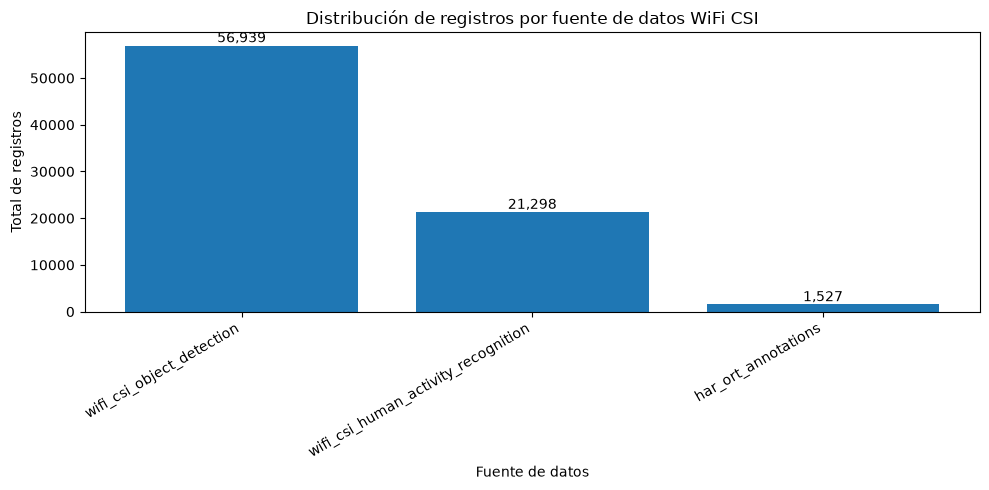

,source_dataset,total_registros
2,wifi_csi_object_detection,56939
1,wifi_csi_human_activity_recognition,21298
0,har_ort_annotations,1527


In [77]:
viz_fuentes = (
    fact_wifi_csi_capture
    .merge(dim_source, on="source_key", how="left")
    .groupby("source_dataset")
    .agg(total_registros=("capture_count", "sum"))
    .reset_index()
    .sort_values("total_registros", ascending=False)
)

plt.figure(figsize=(10, 5))
bars = plt.bar(viz_fuentes["source_dataset"], viz_fuentes["total_registros"])

plt.title("Distribución de registros por fuente de datos WiFi CSI")
plt.xlabel("Fuente de datos")
plt.ylabel("Total de registros")
plt.xticks(rotation=30, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(figures_dir / "fig_01_registros_por_fuente.png", dpi=300)
plt.show()

viz_fuentes

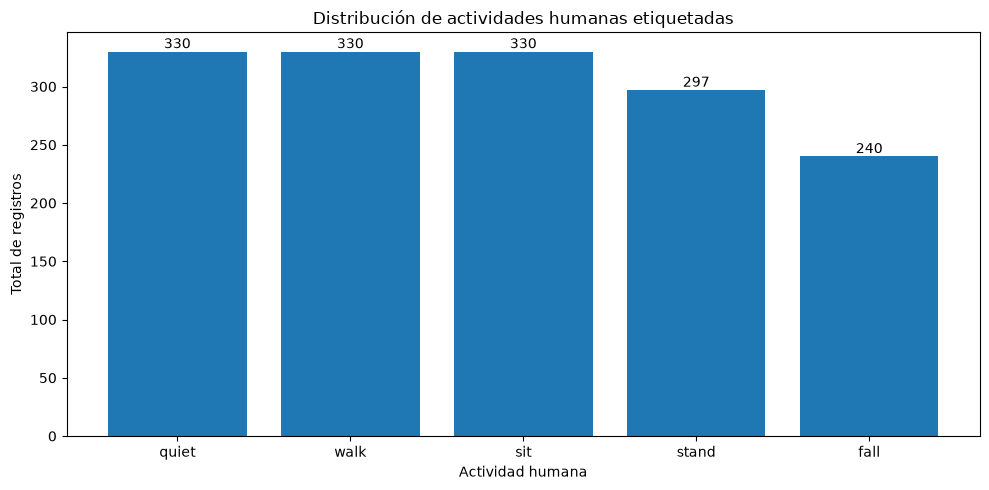

,activity_original,research_label,movement_level,total_registros
1,quiet,control_reposo,sin_movimiento,330
4,walk,movimiento_normal,medio,330
2,sit,actividad_baja,bajo,330
3,stand,actividad_baja,bajo,297
0,fall,caida,critico,240


In [78]:
fact_activity = (
    fact_wifi_csi_capture
    .merge(dim_activity, on="activity_key", how="left")
)

viz_actividades_humanas = fact_activity[
    fact_activity["is_trainable_for_motion_ai"] == 1
].copy()

viz_actividades_humanas = (
    viz_actividades_humanas
    .groupby(["activity_original", "research_label", "movement_level"])
    .agg(total_registros=("capture_count", "sum"))
    .reset_index()
    .sort_values("total_registros", ascending=False)
)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    viz_actividades_humanas["activity_original"],
    viz_actividades_humanas["total_registros"]
)

plt.title("Distribución de actividades humanas etiquetadas")
plt.xlabel("Actividad humana")
plt.ylabel("Total de registros")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(figures_dir / "fig_02_actividades_humanas_etiquetadas.png", dpi=300)
plt.show()

viz_actividades_humanas

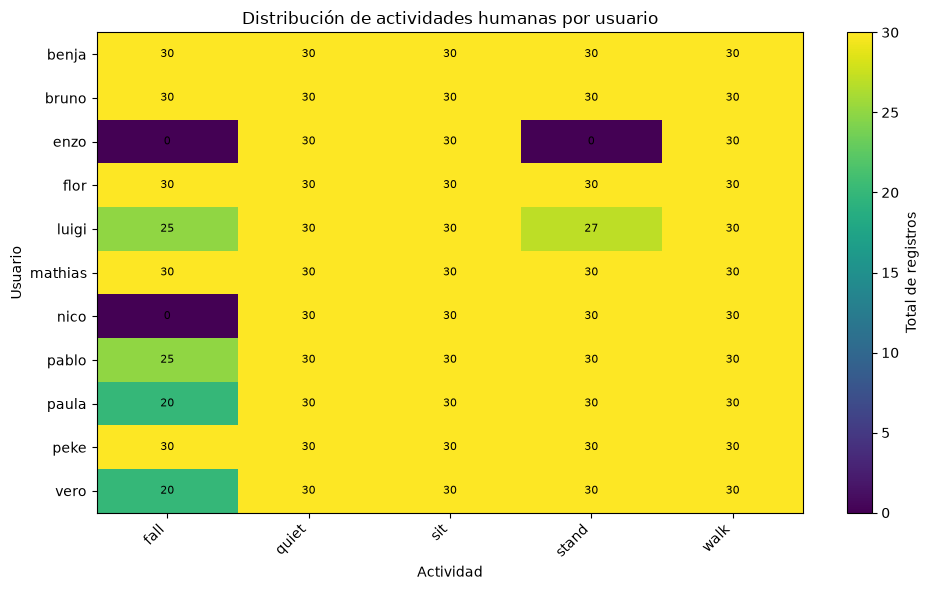

activity_original,fall,quiet,sit,stand,walk
user_id,,,,,
benja,30,30,30,30,30
bruno,30,30,30,30,30
enzo,0,30,30,0,30
flor,30,30,30,30,30
luigi,25,30,30,27,30
mathias,30,30,30,30,30
nico,0,30,30,30,30
pablo,25,30,30,30,30
paula,20,30,30,30,30


In [79]:
fact_human = (
    fact_wifi_csi_capture
    .merge(dim_activity, on="activity_key", how="left")
    .merge(dim_user, on="user_key", how="left")
)

fact_human = fact_human[
    fact_human["is_trainable_for_motion_ai"] == 1
].copy()

matriz_usuario_actividad = pd.crosstab(
    fact_human["user_id"],
    fact_human["activity_original"]
)

plt.figure(figsize=(10, 6))
plt.imshow(matriz_usuario_actividad, aspect="auto")

plt.title("Distribución de actividades humanas por usuario")
plt.xlabel("Actividad")
plt.ylabel("Usuario")

plt.xticks(
    range(len(matriz_usuario_actividad.columns)),
    matriz_usuario_actividad.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(matriz_usuario_actividad.index)),
    matriz_usuario_actividad.index
)

plt.colorbar(label="Total de registros")

for i in range(len(matriz_usuario_actividad.index)):
    for j in range(len(matriz_usuario_actividad.columns)):
        valor = matriz_usuario_actividad.iloc[i, j]
        plt.text(j, i, valor, ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(figures_dir / "fig_03_usuario_vs_actividad.png", dpi=300)
plt.show()

matriz_usuario_actividad

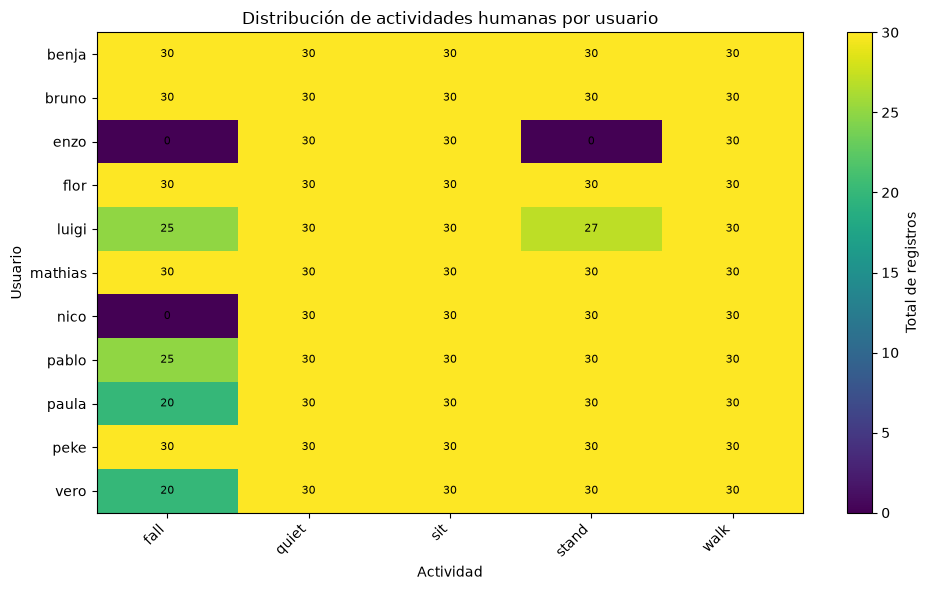

activity_original,fall,quiet,sit,stand,walk
user_id,,,,,
benja,30,30,30,30,30
bruno,30,30,30,30,30
enzo,0,30,30,0,30
flor,30,30,30,30,30
luigi,25,30,30,27,30
mathias,30,30,30,30,30
nico,0,30,30,30,30
pablo,25,30,30,30,30
paula,20,30,30,30,30


In [80]:
fact_human = (
    fact_wifi_csi_capture
    .merge(dim_activity, on="activity_key", how="left")
    .merge(dim_user, on="user_key", how="left")
)

fact_human = fact_human[
    fact_human["is_trainable_for_motion_ai"] == 1
].copy()

matriz_usuario_actividad = pd.crosstab(
    fact_human["user_id"],
    fact_human["activity_original"]
)

plt.figure(figsize=(10, 6))
plt.imshow(matriz_usuario_actividad, aspect="auto")

plt.title("Distribución de actividades humanas por usuario")
plt.xlabel("Actividad")
plt.ylabel("Usuario")

plt.xticks(
    range(len(matriz_usuario_actividad.columns)),
    matriz_usuario_actividad.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(matriz_usuario_actividad.index)),
    matriz_usuario_actividad.index
)

plt.colorbar(label="Total de registros")

for i in range(len(matriz_usuario_actividad.index)):
    for j in range(len(matriz_usuario_actividad.columns)):
        valor = matriz_usuario_actividad.iloc[i, j]
        plt.text(j, i, valor, ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(figures_dir / "fig_03_usuario_vs_actividad.png", dpi=300)
plt.show()

matriz_usuario_actividad

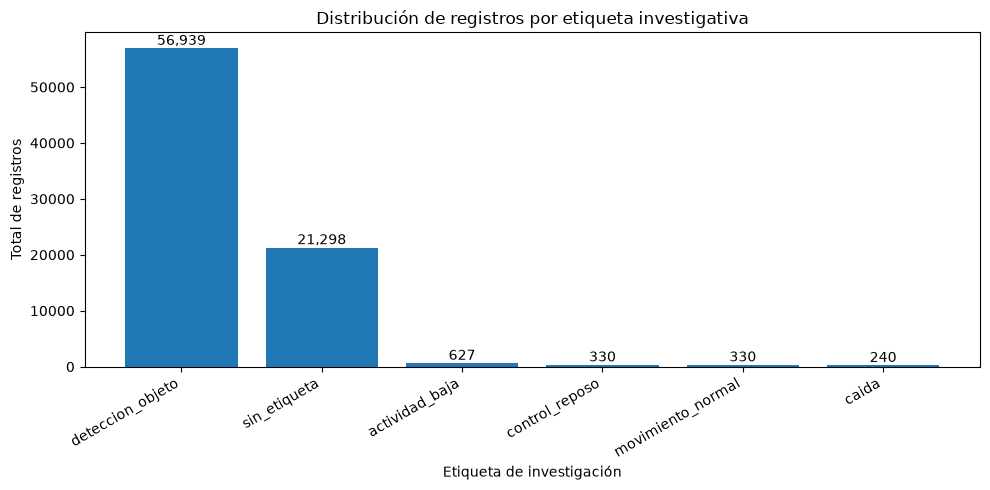

,research_label,movement_level,total_registros
3,deteccion_objeto,no_aplica,56939
5,sin_etiqueta,desconocido,21298
0,actividad_baja,bajo,627
2,control_reposo,sin_movimiento,330
4,movimiento_normal,medio,330
1,caida,critico,240


In [81]:
viz_research_label = (
    fact_wifi_csi_capture
    .merge(dim_activity, on="activity_key", how="left")
    .groupby(["research_label", "movement_level"])
    .agg(total_registros=("capture_count", "sum"))
    .reset_index()
    .sort_values("total_registros", ascending=False)
)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    viz_research_label["research_label"],
    viz_research_label["total_registros"]
)

plt.title("Distribución de registros por etiqueta investigativa")
plt.xlabel("Etiqueta de investigación")
plt.ylabel("Total de registros")
plt.xticks(rotation=30, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(figures_dir / "fig_04_registros_por_etiqueta_investigativa.png", dpi=300)
plt.show()

viz_research_label

In [82]:
print("Figuras generadas:")

for fig in figures_dir.glob("*.png"):
    print(fig)

Figuras generadas:
c:\Users\Manuel\Desktop\proyectoWifi\data\processed\figures\fig_01_registros_por_fuente.png
c:\Users\Manuel\Desktop\proyectoWifi\data\processed\figures\fig_02_actividades_humanas_etiquetadas.png
c:\Users\Manuel\Desktop\proyectoWifi\data\processed\figures\fig_03_usuario_vs_actividad.png
c:\Users\Manuel\Desktop\proyectoWifi\data\processed\figures\fig_04_registros_por_etiqueta_investigativa.png


In [83]:
viz_dir = PROCESSED_DIR / "visualizations_data"
viz_dir.mkdir(parents=True, exist_ok=True)

viz_fuentes.to_csv(viz_dir / "viz_fuentes.csv", index=False, encoding="utf-8")
viz_actividades_humanas.to_csv(viz_dir / "viz_actividades_humanas.csv", index=False, encoding="utf-8")
matriz_usuario_actividad.to_csv(viz_dir / "matriz_usuario_actividad.csv", encoding="utf-8")
viz_research_label.to_csv(viz_dir / "viz_research_label.csv", index=False, encoding="utf-8")

print("Tablas de visualización exportadas en:")
print(viz_dir)

Tablas de visualización exportadas en:
c:\Users\Manuel\Desktop\proyectoWifi\data\processed\visualizations_data


### Interpretación de la Fase 6

Las visualizaciones generadas permitieron interpretar la composición del corpus WiFi CSI consolidado y validar su utilidad para el análisis de movimiento humano.

La primera visualización muestra que el dataset `wifi_csi_object_detection` concentra la mayor cantidad de registros, con 56.939 observaciones, seguido por `wifi_csi_human_activity_recognition`, con 21.298 registros, y `har_ort_annotations`, con 1.527 registros. Esto evidencia que el corpus es heterogéneo y que cada fuente cumple una función distinta dentro del proyecto.

La segunda visualización se enfoca en el subconjunto de actividades humanas etiquetadas. Se observa que las actividades `quiet`, `walk` y `sit` tienen 330 registros cada una, mientras que `stand` cuenta con 297 registros y `fall` con 240 registros. Esta distribución es relevante para una futura etapa de entrenamiento de modelos de inteligencia artificial, ya que permite identificar posibles desbalances entre clases.

La tercera visualización muestra la relación entre usuarios y actividades. La matriz permite identificar qué sujetos tienen registros para cada actividad y facilita la detección de vacíos en la cobertura de datos. Este análisis es importante para evitar sesgos en futuros modelos de clasificación de movimiento.

Finalmente, la visualización por etiqueta investigativa permite clasificar los registros según su utilidad dentro del proyecto: detección de objetos, muestras sin etiqueta, actividad baja, control en reposo, movimiento normal y caída. Esta clasificación fortalece la trazabilidad del corpus y permite orientar el análisis hacia el uso de redes WiFi CSI para detección de movimiento humano.

## Fase 7. Exportación final del modelo estrella para carga en AWS

### Objetivo de la fase

El objetivo de esta fase es preparar los archivos finales del modelo estrella para su posterior carga en Amazon S3 y Amazon Redshift. Para ello, se exportan todas las dimensiones y la tabla de hechos en formato CSV, utilizando nombres estandarizados y una carpeta específica para la carga final.

### Relación con el entregable de Semana 3

Esta fase responde al requerimiento de generar los archivos CSV finales de todos los dataframes del modelo estrella. Estos archivos serán utilizados posteriormente para realizar la carga hacia S3 y Redshift.

### Relación con el paper

Desde la perspectiva investigativa, esta exportación permite dejar una versión estructurada, reproducible y reutilizable del corpus WiFi CSI. Esto facilita que en futuras fases se puedan consultar, analizar o transformar los datos sin depender directamente de los archivos originales.

In [84]:
aws_export_dir = PROCESSED_DIR / "aws_redshift_export"
aws_export_dir.mkdir(parents=True, exist_ok=True)

print("Carpeta de exportación final:")
print(aws_export_dir)

Carpeta de exportación final:
c:\Users\Manuel\Desktop\proyectoWifi\data\processed\aws_redshift_export


In [85]:
tablas_modelo_estrella = {
    "dim_source": dim_source,
    "dim_activity": dim_activity,
    "dim_user": dim_user,
    "dim_file": dim_file,
    "dim_object": dim_object,
    "dim_position": dim_position,
    "dim_configuration": dim_configuration,
    "dim_time": dim_time,
    "dim_label_quality": dim_label_quality,
    "fact_wifi_csi_capture": fact_wifi_csi_capture
}

for nombre_tabla, dataframe in tablas_modelo_estrella.items():
    print(nombre_tabla, dataframe.shape)

dim_source (3, 3)
dim_activity (7, 10)
dim_user (12, 2)
dim_file (1528, 4)
dim_object (7, 3)
dim_position (12, 2)
dim_configuration (3, 2)
dim_time (1528, 8)
dim_label_quality (3, 6)
fact_wifi_csi_capture (79764, 25)


In [86]:
def preparar_dataframe_para_csv(df):
    """
    Prepara un DataFrame para exportación CSV compatible con carga en Redshift.
    """
    df_export = df.copy()

    for col in df_export.columns:
        if df_export[col].dtype == "object":
            df_export[col] = (
                df_export[col]
                .fillna("no_aplica")
                .astype(str)
                .str.replace("\n", " ", regex=False)
                .str.replace("\r", " ", regex=False)
                .str.replace('"', "'", regex=False)
            )
        else:
            df_export[col] = df_export[col].fillna(0)

    return df_export

In [87]:
archivos_exportados = []

for nombre_tabla, dataframe in tablas_modelo_estrella.items():
    df_export = preparar_dataframe_para_csv(dataframe)

    ruta_salida = aws_export_dir / f"{nombre_tabla}.csv"

    df_export.to_csv(
        ruta_salida,
        index=False,
        encoding="utf-8"
    )

    archivos_exportados.append({
        "table_name": nombre_tabla,
        "file_name": f"{nombre_tabla}.csv",
        "path": str(ruta_salida),
        "rows": df_export.shape[0],
        "columns": df_export.shape[1]
    })

resumen_exportacion = pd.DataFrame(archivos_exportados)
resumen_exportacion

,table_name,file_name,path,rows,columns
0,dim_source,dim_source.csv,c:\Users\Manuel\Desktop\proyectoWifi\data\proc...,3,3
1,dim_activity,dim_activity.csv,c:\Users\Manuel\Desktop\proyectoWifi\data\proc...,7,10
2,dim_user,dim_user.csv,c:\Users\Manuel\Desktop\proyectoWifi\data\proc...,12,2
3,dim_file,dim_file.csv,c:\Users\Manuel\Desktop\proyectoWifi\data\proc...,1528,4
4,dim_object,dim_object.csv,c:\Users\Manuel\Desktop\proyectoWifi\data\proc...,7,3
5,dim_position,dim_position.csv,c:\Users\Manuel\Desktop\proyectoWifi\data\proc...,12,2
6,dim_configuration,dim_configuration.csv,c:\Users\Manuel\Desktop\proyectoWifi\data\proc...,3,2
7,dim_time,dim_time.csv,c:\Users\Manuel\Desktop\proyectoWifi\data\proc...,1528,8
8,dim_label_quality,dim_label_quality.csv,c:\Users\Manuel\Desktop\proyectoWifi\data\proc...,3,6
9,fact_wifi_csi_capture,fact_wifi_csi_capture.csv,c:\Users\Manuel\Desktop\proyectoWifi\data\proc...,79764,25


In [88]:
print("Archivos CSV generados para AWS/Redshift:")

for file in aws_export_dir.glob("*.csv"):
    print(file.name)

Archivos CSV generados para AWS/Redshift:
dim_activity.csv
dim_configuration.csv
dim_file.csv
dim_label_quality.csv
dim_object.csv
dim_position.csv
dim_source.csv
dim_time.csv
dim_user.csv
fact_wifi_csi_capture.csv


In [89]:
validacion_archivos = []

for file in aws_export_dir.glob("*.csv"):
    df_temp = pd.read_csv(file)

    validacion_archivos.append({
        "file_name": file.name,
        "rows": df_temp.shape[0],
        "columns": df_temp.shape[1],
        "is_empty": df_temp.empty
    })

validacion_archivos = pd.DataFrame(validacion_archivos)
validacion_archivos

,file_name,rows,columns,is_empty
0,dim_activity.csv,7,10,False
1,dim_configuration.csv,3,2,False
2,dim_file.csv,1528,4,False
3,dim_label_quality.csv,3,6,False
4,dim_object.csv,7,3,False
5,dim_position.csv,12,2,False
6,dim_source.csv,3,3,False
7,dim_time.csv,1528,8,False
8,dim_user.csv,12,2,False
9,fact_wifi_csi_capture.csv,79764,25,False


In [90]:
resumen_exportacion.to_csv(
    aws_export_dir / "resumen_exportacion_modelo_estrella.csv",
    index=False,
    encoding="utf-8"
)

validacion_archivos.to_csv(
    aws_export_dir / "validacion_archivos_exportados.csv",
    index=False,
    encoding="utf-8"
)

print("Resumen de exportación guardado en:")
print(aws_export_dir)

Resumen de exportación guardado en:
c:\Users\Manuel\Desktop\proyectoWifi\data\processed\aws_redshift_export


### Interpretación de la Fase 7

En esta fase se exportaron los archivos finales del modelo estrella en formato CSV, dejando lista la estructura para su posterior carga en Amazon S3 y Amazon Redshift.

Se generaron las dimensiones `dim_source`, `dim_activity`, `dim_user`, `dim_file`, `dim_object`, `dim_position`, `dim_configuration`, `dim_time` y `dim_label_quality`, junto con la tabla de hechos `fact_wifi_csi_capture`.

La validación confirmó que los archivos fueron creados correctamente y que conservan el número de registros esperado. Esta exportación permite contar con una versión estructurada y reutilizable del modelo analítico WiFi CSI, adecuada tanto para el entregable de la Semana 3 como para futuras fases de investigación sobre detección de movimiento humano mediante señales WiFi CSI.

## Fase 8. Configuración de AWS, Amazon S3 y Amazon Redshift

### Objetivo de la fase

El objetivo de esta fase es preparar la infraestructura en AWS para realizar la carga final del modelo estrella. Para ello se configura un bucket en Amazon S3, un entorno de Amazon Redshift Serverless y las variables necesarias para conectar el notebook con los servicios de AWS.

### Relación con el entregable de Semana 3

Esta fase responde al requerimiento de configurar AWS, documentar la creación del bucket S3, evidenciar la configuración de Redshift Serverless y preparar la carga de los archivos CSV generados en la fase anterior.

### Relación con el paper

Desde la perspectiva investigativa, esta fase permite dejar el corpus WiFi CSI en una plataforma analítica escalable. Esto facilita la consulta, trazabilidad y reutilización de los datos para futuras etapas de análisis, extracción de características y entrenamiento de modelos de inteligencia artificial.

In [13]:
import os
from dotenv import load_dotenv

load_dotenv()

print("Bucket:", os.getenv("S3_BUCKET"))
print("Región:", os.getenv("AWS_DEFAULT_REGION"))
print("Access key cargada:", "Sí" if os.getenv("AWS_ACCESS_KEY_ID") else "No")

Bucket: wifi-csi-g10-semana3
Región: sa-east-1
Access key cargada: Sí


In [2]:
import os
from dotenv import load_dotenv
import boto3

load_dotenv()

bucket = os.getenv("S3_BUCKET")
prefix = os.getenv("S3_PREFIX", "semana3")

s3 = boto3.client("s3")

response = s3.list_objects_v2(
    Bucket=bucket,
    Prefix=prefix
)

print("Conexión correcta con S3")
print("Bucket:", bucket)
print("Prefix:", prefix)

for obj in response.get("Contents", []):
    print(obj["Key"])

Conexión correcta con S3
Bucket: wifi-csi-g10-semana3
Prefix: semana3
semana3/


In [3]:
import os
from pathlib import Path
from dotenv import load_dotenv
import boto3

load_dotenv()

bucket = os.getenv("S3_BUCKET")
prefix = os.getenv("S3_PREFIX", "semana3")

s3 = boto3.client("s3")

export_dir = Path("data/processed/aws_redshift_export")

csv_files = list(export_dir.glob("*.csv"))

print(f"Archivos encontrados: {len(csv_files)}")

for file_path in csv_files:
    s3_key = f"{prefix}/{file_path.name}"

    s3.upload_file(
        Filename=str(file_path),
        Bucket=bucket,
        Key=s3_key
    )

    print(f"Subido: s3://{bucket}/{s3_key}")

Archivos encontrados: 12
Subido: s3://wifi-csi-g10-semana3/semana3/dim_activity.csv
Subido: s3://wifi-csi-g10-semana3/semana3/dim_configuration.csv
Subido: s3://wifi-csi-g10-semana3/semana3/dim_file.csv
Subido: s3://wifi-csi-g10-semana3/semana3/dim_label_quality.csv
Subido: s3://wifi-csi-g10-semana3/semana3/dim_object.csv
Subido: s3://wifi-csi-g10-semana3/semana3/dim_position.csv
Subido: s3://wifi-csi-g10-semana3/semana3/dim_source.csv
Subido: s3://wifi-csi-g10-semana3/semana3/dim_time.csv
Subido: s3://wifi-csi-g10-semana3/semana3/dim_user.csv
Subido: s3://wifi-csi-g10-semana3/semana3/fact_wifi_csi_capture.csv
Subido: s3://wifi-csi-g10-semana3/semana3/resumen_exportacion_modelo_estrella.csv
Subido: s3://wifi-csi-g10-semana3/semana3/validacion_archivos_exportados.csv


In [10]:
import os
from dotenv import load_dotenv
import redshift_connector

load_dotenv(override=True)

conn = redshift_connector.connect(
    host=os.getenv("REDSHIFT_HOST"),
    database=os.getenv("REDSHIFT_DATABASE"),
    user=os.getenv("REDSHIFT_USER"),
    password=os.getenv("REDSHIFT_PASSWORD"),
    port=int(os.getenv("REDSHIFT_PORT", 5439)),
    ssl=True
)

cursor = conn.cursor()
cursor.execute("SELECT 1;")

print("Conexión correcta a Redshift")

cursor.close()
conn.close()

Conexión correcta a Redshift


In [11]:
import os
from pathlib import Path
import pandas as pd
from dotenv import load_dotenv
import redshift_connector

load_dotenv(override=True)

EXPORT_DIR = Path("data/processed/aws_redshift_export")

S3_BUCKET = os.getenv("S3_BUCKET")
S3_PREFIX = os.getenv("S3_PREFIX", "semana3")
IAM_ROLE = os.getenv("REDSHIFT_IAM_ROLE")
REGION = os.getenv("AWS_DEFAULT_REGION", "sa-east-1")

conn = redshift_connector.connect(
    host=os.getenv("REDSHIFT_HOST"),
    database=os.getenv("REDSHIFT_DATABASE"),
    user=os.getenv("REDSHIFT_USER"),
    password=os.getenv("REDSHIFT_PASSWORD"),
    port=int(os.getenv("REDSHIFT_PORT", 5439)),
    ssl=True
)

cursor = conn.cursor()

cursor.execute("CREATE SCHEMA IF NOT EXISTS wifi_csi;")
conn.commit()

def clean_column_name(col):
    return (
        str(col)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace(".", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

def infer_redshift_type(series):
    if pd.api.types.is_integer_dtype(series):
        return "BIGINT"
    if pd.api.types.is_float_dtype(series):
        return "DOUBLE PRECISION"
    if pd.api.types.is_bool_dtype(series):
        return "BOOLEAN"
    return "VARCHAR(1000)"

def create_table_from_csv(csv_path):
    table_name = csv_path.stem
    df = pd.read_csv(csv_path, nrows=200)

    columns_sql = []
    for col in df.columns:
        clean_col = clean_column_name(col)
        redshift_type = infer_redshift_type(df[col])
        columns_sql.append(f'"{clean_col}" {redshift_type}')

    cursor.execute(f'DROP TABLE IF EXISTS wifi_csi."{table_name}";')
    cursor.execute(f'''
        CREATE TABLE wifi_csi."{table_name}" (
            {", ".join(columns_sql)}
        );
    ''')
    conn.commit()

    print(f"Tabla creada: {table_name}")

def load_file(csv_path):
    table_name = csv_path.stem
    s3_path = f"s3://{S3_BUCKET}/{S3_PREFIX}/{csv_path.name}"

    cursor.execute(f'''
        COPY wifi_csi."{table_name}"
        FROM '{s3_path}'
        IAM_ROLE '{IAM_ROLE}'
        REGION '{REGION}'
        CSV
        IGNOREHEADER 1
        ACCEPTINVCHARS
        BLANKSASNULL
        EMPTYASNULL;
    ''')
    conn.commit()

    print(f"Tabla cargada: {table_name}")

csv_files = [
    path for path in EXPORT_DIR.glob("*.csv")
    if path.name.startswith("dim_") or path.name.startswith("fact_")
]

for csv_file in csv_files:
    create_table_from_csv(csv_file)

for csv_file in csv_files:
    load_file(csv_file)

cursor.close()
conn.close()

print("Carga finalizada correctamente")

Tabla creada: dim_activity
Tabla creada: dim_configuration
Tabla creada: dim_file
Tabla creada: dim_label_quality
Tabla creada: dim_object
Tabla creada: dim_position
Tabla creada: dim_source
Tabla creada: dim_time
Tabla creada: dim_user
Tabla creada: fact_wifi_csi_capture
Tabla cargada: dim_activity
Tabla cargada: dim_configuration
Tabla cargada: dim_file
Tabla cargada: dim_label_quality
Tabla cargada: dim_object
Tabla cargada: dim_position
Tabla cargada: dim_source
Tabla cargada: dim_time
Tabla cargada: dim_user
Tabla cargada: fact_wifi_csi_capture
Carga finalizada correctamente


In [12]:
import os
from dotenv import load_dotenv
import redshift_connector

load_dotenv(override=True)

tables = [
    "dim_activity",
    "dim_configuration",
    "dim_file",
    "dim_label_quality",
    "dim_object",
    "dim_position",
    "dim_source",
    "dim_time",
    "dim_user",
    "fact_wifi_csi_capture"
]

conn = redshift_connector.connect(
    host=os.getenv("REDSHIFT_HOST"),
    database=os.getenv("REDSHIFT_DATABASE"),
    user=os.getenv("REDSHIFT_USER"),
    password=os.getenv("REDSHIFT_PASSWORD"),
    port=int(os.getenv("REDSHIFT_PORT", 5439)),
    ssl=True
)

cursor = conn.cursor()

for table in tables:
    cursor.execute(f'SELECT COUNT(*) FROM wifi_csi."{table}";')
    total = cursor.fetchone()[0]
    print(f"{table}: {total} registros")

cursor.close()
conn.close()

print("Validación finalizada correctamente")

dim_activity: 7 registros
dim_configuration: 3 registros
dim_file: 1528 registros
dim_label_quality: 3 registros
dim_object: 7 registros
dim_position: 12 registros
dim_source: 3 registros
dim_time: 1528 registros
dim_user: 12 registros
fact_wifi_csi_capture: 79764 registros
Validación finalizada correctamente


## Validación de carga del modelo estrella en Redshift

En esta sección se ejecutan consultas SQL desde Python para validar que el modelo estrella fue cargado correctamente en Amazon Redshift. Se verifica la existencia de las tablas, el número de registros cargados y una consulta analítica mediante JOIN entre la tabla de hechos y sus dimensiones.

In [6]:
import os
import pandas as pd
import redshift_connector
from dotenv import load_dotenv
from pathlib import Path

load_dotenv(dotenv_path=Path.cwd() / ".env", override=True)

conn = redshift_connector.connect(
    host=os.getenv("REDSHIFT_HOST"),
    port=int(os.getenv("REDSHIFT_PORT")),
    database=os.getenv("REDSHIFT_DATABASE"),
    user=os.getenv("REDSHIFT_USER"),
    password=os.getenv("REDSHIFT_PASSWORD"),
    ssl=True,
    sslmode="require",
    timeout=30
)

conn.autocommit = True
cursor = conn.cursor()

print("Conexión a Redshift realizada correctamente con SSL")

Conexión a Redshift realizada correctamente con SSL


In [7]:
cursor.execute("SELECT current_database(), current_user;")
cursor.fetchall()

(['dev', 'adminWifi'],)

In [8]:
def ejecutar_consulta(sql):
    cursor.execute(sql)
    columnas = [desc[0] for desc in cursor.description]
    resultados = cursor.fetchall()
    return pd.DataFrame(resultados, columns=columnas)

In [9]:
sql_tablas = """
SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name;
"""

df_tablas_redshift = ejecutar_consulta(sql_tablas)
df_tablas_redshift

,table_schema,table_name


In [11]:
sql_tablas_todos_esquemas = """
SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_schema NOT IN ('pg_catalog', 'information_schema')
ORDER BY table_schema, table_name;
"""

df_tablas_todos_esquemas = ejecutar_consulta(sql_tablas_todos_esquemas)
df_tablas_todos_esquemas

,table_schema,table_name
0,pg_auto_copy,copy_job_detail
1,pg_internal,redshift_auto_health_check_
2,wifi_csi,dim_activity
3,wifi_csi,dim_configuration
4,wifi_csi,dim_file
5,wifi_csi,dim_label_quality
6,wifi_csi,dim_object
7,wifi_csi,dim_position
8,wifi_csi,dim_source
9,wifi_csi,dim_time


In [13]:
sql_conteos = """
SELECT 'dim_activity' AS tabla, COUNT(*) AS registros FROM wifi_csi.dim_activity
UNION ALL
SELECT 'dim_configuration', COUNT(*) FROM wifi_csi.dim_configuration
UNION ALL
SELECT 'dim_file', COUNT(*) FROM wifi_csi.dim_file
UNION ALL
SELECT 'dim_label_quality', COUNT(*) FROM wifi_csi.dim_label_quality
UNION ALL
SELECT 'dim_object', COUNT(*) FROM wifi_csi.dim_object
UNION ALL
SELECT 'dim_position', COUNT(*) FROM wifi_csi.dim_position
UNION ALL
SELECT 'dim_source', COUNT(*) FROM wifi_csi.dim_source
UNION ALL
SELECT 'dim_time', COUNT(*) FROM wifi_csi.dim_time
UNION ALL
SELECT 'dim_user', COUNT(*) FROM wifi_csi.dim_user
UNION ALL
SELECT 'fact_wifi_csi_capture', COUNT(*) FROM wifi_csi.fact_wifi_csi_capture;
"""

df_conteos_redshift = ejecutar_consulta(sql_conteos)
df_conteos_redshift

,tabla,registros
0,dim_position,12
1,dim_source,3
2,dim_configuration,3
3,dim_time,1528
4,dim_file,1528
5,dim_label_quality,3
6,dim_user,12
7,dim_object,7
8,fact_wifi_csi_capture,79764
9,dim_activity,7


In [14]:
sql_validacion_modelo = """
SELECT 
    s.source_dataset,
    a.research_label,
    a.movement_level,
    SUM(f.capture_count) AS total_registros
FROM wifi_csi.fact_wifi_csi_capture f
JOIN wifi_csi.dim_source s 
    ON f.source_key = s.source_key
JOIN wifi_csi.dim_activity a 
    ON f.activity_key = a.activity_key
GROUP BY 
    s.source_dataset,
    a.research_label,
    a.movement_level
ORDER BY total_registros DESC;
"""

df_validacion_modelo = ejecutar_consulta(sql_validacion_modelo)
df_validacion_modelo

,source_dataset,research_label,movement_level,total_registros
0,wifi_csi_object_detection,deteccion_objeto,no_aplica,56939
1,wifi_csi_human_activity_recognition,sin_etiqueta,desconocido,21298
2,har_ort_annotations,actividad_baja,bajo,627
3,har_ort_annotations,control_reposo,sin_movimiento,330
4,har_ort_annotations,movimiento_normal,medio,330
5,har_ort_annotations,caida,critico,240


In [15]:
cursor.execute("SET search_path TO wifi_csi;")

### Validación del esquema de carga en Redshift

Durante la validación se identificó que las tablas del modelo estrella fueron cargadas en el esquema `wifi_csi` y no en el esquema `public`. Por esta razón, las consultas de validación se ejecutaron utilizando el nombre completo de cada tabla, por ejemplo `wifi_csi.dim_activity` y `wifi_csi.fact_wifi_csi_capture`.

La consulta sobre `information_schema.tables` confirmó la existencia de las dimensiones y la tabla de hechos dentro del esquema `wifi_csi`, evidenciando que el modelo estrella fue cargado correctamente en Amazon Redshift.

## Reflexión individual 

`Manuel Vicente`

En mi entorno laboral aplicaría este proceso ETL en actividades relacionadas con pruebas DLP, análisis de vulnerabilidades, revisión de logs y reportes generados por herramientas de seguridad. Las fuentes principales serían reportes de DLP, eventos enviados al SOC/SIEM, registros de navegación web, alertas de seguridad, inventarios de equipos, usuarios de Directorio Activo y resultados de scripts o GPO aplicadas a la infraestructura.

El objetivo sería consolidar esta información para mejorar las configuraciones actuales, reducir el ruido operativo, optimizar el rendimiento de equipos e infraestructura tecnológica, y obtener resultados más seguros y confiables. En la etapa de transformación aplicaría limpieza de datos, corrección de marcas de tiempo por diferencias horarias, tratamiento de valores nulos, traducción de campos en inglés, creación de catálogos y normalización de nomenclaturas.

La tabla contenedora central estaría orientada al comportamiento humano y tecnológico, integrando variables como uso de aplicaciones, tiempo de navegación, alertas generadas, accesos web, actividades inusuales con archivos y visitas a sitios no productivos. A partir de esta base construiría dimensiones como usuario, equipo, área, fecha, tipo de evento, severidad y herramienta de origen. La tabla de hechos registraría eventos de seguridad, archivos bloqueados, equipos sin nodo, usuarios afectados, incidentes por área y actividades inusuales.

Las visualizaciones permitirían mostrar eventos por área, usuarios con más alertas, tendencias mensuales, equipos con mayor riesgo y niveles de severidad. Aunque el uso de nube puede ser útil, al tratarse de un entorno financiero se debe considerar una infraestructura segura, regulada y apropiada. Este proceso ayudaría a mejorar la productividad del departamento de Seguridad de la Información y entregaría evidencias claras para que gerencia tenga un panorama directo para la toma de decisiones. Como mejora futura, incorporaría modelos predictivos para anticipar riesgos.


`Klever Barahona`


En mi entorno profesional me desempeño como Analista Informático y dentro de mis actividades se encuentran el análisis de información institucional, seguimiento de matrices de riesgos, registros de actividades de tratamiento de datos personales (RAT), evaluaciones de cumplimiento y generación de reportes para la toma de decisiones.

La implementación de un proceso de carga como el desarrollado en esta práctica podría aplicarse para centralizar información proveniente de diferentes áreas institucionales. Por ejemplo, los registros de actividades de tratamiento, las evaluaciones de cumplimiento normativo, los incidentes de seguridad y los indicadores de gestión podrían ser extraídos desde archivos Excel, bases de datos institucionales y otros sistemas corporativos.

Posteriormente, mediante procesos ETL desarrollados en Python, la información sería validada, depurada y transformada para garantizar su calidad y consistencia. Una vez procesados los datos, estos podrían almacenarse inicialmente en Amazon S3 como repositorio centralizado y posteriormente cargarse hacia Amazon Redshift para construir un Data Warehouse institucional.

Con esta arquitectura sería posible generar tableros de control y análisis históricos que permitan identificar tendencias, medir niveles de cumplimiento, monitorear riesgos de seguridad de la información y evaluar el avance de proyectos relacionados con protección de datos personales.
La principal ventaja de este enfoque sería disponer de información consolidada, confiable y actualizada para apoyar la toma de decisiones estratégicas, optimizar tiempos de análisis y mejorar la capacidad de respuesta ante riesgos o incumplimientos detectados dentro de la institución.


`ELVIS BORBOR`

En esta parte en la que se desarrolla la ultima fase del sistema ETL, nos fijamos que el proceso de carga depende bastante de cómo fue transformada la base explorada. La creación de las dimensiones y tabla de hechos para la data permitió llevar al siguiente nivel lo explorado, específicamente llevar a la nube a través de AWS lo extraído.

Basándonos en nuestro entorno laboral podemos identificar que a través del ejemplo siguiente conseguiremos un modelo estrella que permite analizar la data desde un archivo CSV.

El archivo es descargado de la consola INTUNE que posee la organización, el archivo contiene básicamente el hostname de equipos en producción, IPs de los equipos, usuario logeado, última fecha de sincronización, la serie del equipo, tipo de sistema operativo, compilación de sistema operativo.

Basándonos en el proceso de exploración de la data podemos entender que la estructura a construir puede girar en torno a la serie del equipo pues es un identificador único que nunca cambia en los equipos, la misma puede verse reflejada en la tabla principal y lograr la transformación que se necesita para obtener una buena analítica de la data.

En el proceso de Transformación construiremos varios dataframes que permitirán obtener una nueva data y que permite analizar los datos extraídos, los dataframes pueden incluir en esta fase equipos en producción, equipos duplicados, equipos con usuarios logeados, equipos con ultima compilación de sistema operativo. Los scripts a construir deben permitir eliminar las columnas de valores nulos o en blanco. Al final debemos construir el Docker Compose en esta fase que será la base solida de nuestra estructura y en el siguiente nivel poder realizar el proceso de carga.

En la siguiente fase construiremos un modelo estrella que permita analizar los datos obtenidos, este modelo permitirá analizar en una nueva tabla de hechos los equipos en producción y actualizados en su sistema operativo. Este modelo estrella gira en torno a los equipos en producción equipos únicos que no se repiten cuyo hostname permita analizar que equipo esta o no actualizado en nuestra organización, esto es obtenido de acuerdo a las dimensiones producidas en esta fase.

El proceso de carga se lo realizara en función de lo encontrado según la analítica. Las dimensiones que se relacionan con el hostname y serial del equipo en producción, Otra dimensión que se relaciona es el hostname con el user logeado, una dimensión mas que podemos obtener es relacionar el hostname con el tipo de sistema operativo que posee el equipo. 

Al final para que este proceso tenga su validez absoluta es necesario subir a un repositorio como AWS para presentar a los directivos de la organización y realizarlo tipo target para que sea mas representativo e ilustrativo.


## Cierre del entregable

### Conclusiones generales

En este entregable se completó el proceso de construcción de un modelo analítico basado en datos WiFi CSI, orientado al análisis de movimiento humano y detección de patrones a partir de señales inalámbricas. El proceso inició con el inventario de fuentes, continuó con la consolidación de una tabla contenedora y posteriormente avanzó hacia la construcción de un modelo estrella compuesto por dimensiones y una tabla de hechos.

La tabla contenedora permitió integrar fuentes heterogéneas, manteniendo la trazabilidad de cada registro según su origen, tipo de actividad, usuario, archivo asociado, estado de etiqueta y utilidad investigativa. Esta etapa fue importante porque permitió fortalecer la relación entre las fuentes originales y el modelo final.

El modelo estrella permitió organizar la información en dimensiones como fuente, actividad, usuario, archivo, objeto, posición, configuración, tiempo y calidad de etiqueta. La tabla de hechos `fact_wifi_csi_capture` conservó la totalidad de los registros consolidados, permitiendo realizar análisis desde diferentes perspectivas.

Las visualizaciones generadas facilitaron la interpretación del corpus, mostrando la distribución por fuente, el balance de actividades humanas etiquetadas, la relación entre usuarios y actividades, y la utilidad investigativa de cada grupo de registros.

### Aporte al proyecto de investigación WiFi CSI

Este entregable deja una base estructurada y reutilizable para futuras etapas de investigación sobre detección de movimiento humano mediante redes WiFi CSI. Aunque en esta fase no se entrena todavía un modelo de inteligencia artificial, sí se prepara el corpus de datos para una etapa posterior de extracción de características, análisis de señales y clasificación de actividades.

El subconjunto de actividades humanas etiquetadas permite identificar clases como reposo, movimiento bajo, movimiento normal y caída. Esta organización será útil para formular un problema de clasificación supervisada y evaluar posteriormente modelos de aprendizaje automático orientados a detección de movimiento.

Además, la separación entre registros etiquetados, registros sin etiqueta y registros de detección de objetos permite comprender mejor la utilidad de cada fuente dentro del proyecto, evitando mezclar datos con propósitos distintos.

### Trabajos futuros

Como trabajo futuro se propone continuar con la extracción de características específicas de las señales WiFi CSI, tales como amplitud, fase, variación temporal, patrones por subportadora y métricas estadísticas por ventana de tiempo.

También se plantea entrenar modelos de inteligencia artificial para clasificar actividades humanas, especialmente diferenciando entre ausencia de movimiento, movimiento normal y eventos críticos como caídas. Para ello será necesario evaluar el balance de clases, la calidad de las etiquetas y la separación entre datos de entrenamiento y prueba.

Otra mejora futura sería automatizar el flujo ETL completo, desde la lectura de archivos originales hasta la carga final en una plataforma analítica, permitiendo actualizar el corpus de forma periódica y generar dashboards de seguimiento.

### Checklist final del entregable

* Se realizó el inventario de fuentes de datos WiFi CSI.
* Se construyó una tabla contenedora consolidada.
* Se realizó análisis exploratorio del corpus.
* Se definió una taxonomía de movimiento.
* Se creó el modelo estrella con dimensiones y tabla de hechos.
* Se generaron visualizaciones para interpretar los datos.
* Se exportaron los archivos CSV finales del modelo.
* Se documentó la aplicación individual del proceso en el entorno laboral.
* Se preparó la estructura para la carga en AWS, S3 y Redshift.
* Se generó un documento de configuraciones con evidencias visuales.

### Archivos finales del entregable

Los archivos finales que se deben entregar son:

* `ProyectoG10.ipynb`: notebook con todo el proceso desarrollado y comentado en Markdown.
* `configuracionesAWS_G10.docx`: documento con capturas de configuración, carga y evidencias generadas.

Con este cierre, el entregable queda alineado con el componente práctico de la Semana 3 y, al mismo tiempo, deja una base útil para continuar el desarrollo del paper sobre uso de redes WiFi CSI para detección de movimiento humano.
